<a href="https://colab.research.google.com/github/Pearlyn17/stuff/blob/main/BC3415_Individual_Report_U2210499A.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**BC3415 Individual Report - U2210499A**

In [ ]:
import os
import re
import json
import time
from dataclasses import dataclass
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from scipy.stats import loguniform, randint

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn import metrics

In [ ]:
# --- Paths --- #
OUT_DIR   = "./spam_artifacts"
os.makedirs(OUT_DIR, exist_ok=True)

# --- Runtime/Speed --- #
CV_FOLDS            = 5
N_ITER_LR           = 20
N_ITER_RF           = 25
OPTIMIZE_THRESHOLD  = True
N_JOBS              = -1

# Feature-selection (χ²) candidate sizes; smaller -> faster
SELECT_K_OPTIONS    = [2000, 5000, 10000]

# N-gram range candidates; restrict to (1,1) for speed
NGRAM_RANGE_OPTIONS = [(1,1), (1,2)]

# SVD components for RF pipeline; smaller -> faster
SVD_COMPONENTS      = [100, 200, 300, 400]

# Random Forest tree sizes (smaller depths/estimators train faster)
RF_N_ESTIMATORS_DIST = randint(200, 600)
RF_MAX_DEPTH_OPTIONS = [None, 10, 20, 40]
RF_MIN_SAMPLES_LEAF  = [1, 2, 4]

# --- BERT --- #
SKIP_BERT        = False
BERT_MODEL_NAME  = "bert-base-uncased"  # Google BERT base
BERT_MAX_LEN     = 96
BERT_BATCH_SIZE  = 32
CACHE_BERT_EMB   = True
BERT_CACHE_DIR   = os.path.join(OUT_DIR, "bert_cache")
Path(BERT_CACHE_DIR).mkdir(parents=True, exist_ok=True)


# Data Preprocessing
Inferred text/label columns, normalized labels to {0,1}, cleaned text (URLs → “URL”, digits → “NUM”, stripped punctuation)

Stratified train/test split

Cleaning favors word n-grams; will run char models on raw text to keep numeric/punctuation patterns useful for obfuscated spam

In [ ]:
def clean_text(s):
    s = str(s)
    s = re.sub(r"http\S+|www\.\S+", " URL ", s)
    s = re.sub(r"\d+", " NUM ", s)
    s = re.sub(r"[^a-zA-Z0-9\s]", " ", s)
    s = re.sub(r"\s+", " ", s)
    return s.strip().lower()

def infer_columns(df):
    label_candidates = [c for c in df.columns if c.lower() in {"label", "category", "target", "spam", "is_spam", "class"}]
    text_candidates  = [c for c in df.columns if c.lower() in {"text", "message", "sms", "email", "content", "body"}]
    label_col = label_candidates[0] if label_candidates else None
    text_col  = text_candidates[0] if text_candidates else None
    if label_col is None:
        for c in df.columns:
            nunique = df[c].nunique(dropna=True)
            if nunique in (2, 3) and df[c].dtype == object:
                label_col = c
                break
    if text_col is None:
        obj_cols = [c for c in df.columns if df[c].dtype == object]
        if obj_cols:
            lengths = {c: df[c].astype(str).map(len).mean() for c in obj_cols}
            if label_col in lengths:
                lengths.pop(label_col, None)
            text_col = max(lengths, key=lengths.get) if lengths else obj_cols[0]
    if text_col is None or label_col is None:
        raise RuntimeError(f"Could not infer text/label columns. Columns: {df.columns.tolist()}")
    return text_col, label_col

def normalize_label(series):
    s = series.astype(str).str.lower().str.strip()
    mapping = {
        "spam": 1, "ham": 0,
        "1": 1, "0": 0,
        "yes": 1, "no": 0,
        "true": 1, "false": 0,
        "y": 1, "n": 0,
        "pos": 1, "neg": 0,
        "positive": 1, "negative": 0
    }
    mapped = s.map(lambda x: mapping[x] if x in mapping else x)
    try:
        mapped = pd.to_numeric(mapped)
    except Exception:
        vals = s.unique().tolist()
        if len(vals) != 2:
            raise RuntimeError("Label column must be binary or coercible to binary.")
        counts = s.value_counts()
        ham_like = counts.index[0]  # most frequent -> ham
        mapped = s.apply(lambda x: 0 if x == ham_like else 1)
    return mapped.astype(int)


# Load, Clean, Split

In [ ]:
df = pd.read_csv("spam_data.csv")
text_col, label_col = infer_columns(df)

df = df[[text_col, label_col]].dropna()
df = df.drop_duplicates(subset=[text_col])
df["text_clean"] = df[text_col].map(clean_text)
df["label_bin"]  = normalize_label(df[label_col])

X = df["text_clean"].values
y = df["label_bin"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Inferred text column: {text_col} | label column: {label_col}")
print(f"Train size: {len(X_train)} | Test size: {len(X_test)}")

Inferred text column: v2 | label column: v1
Train size: 4135 | Test size: 1034


# Data Analytics & Visualization

 COMPREHENSIVE DATA ANALYSIS


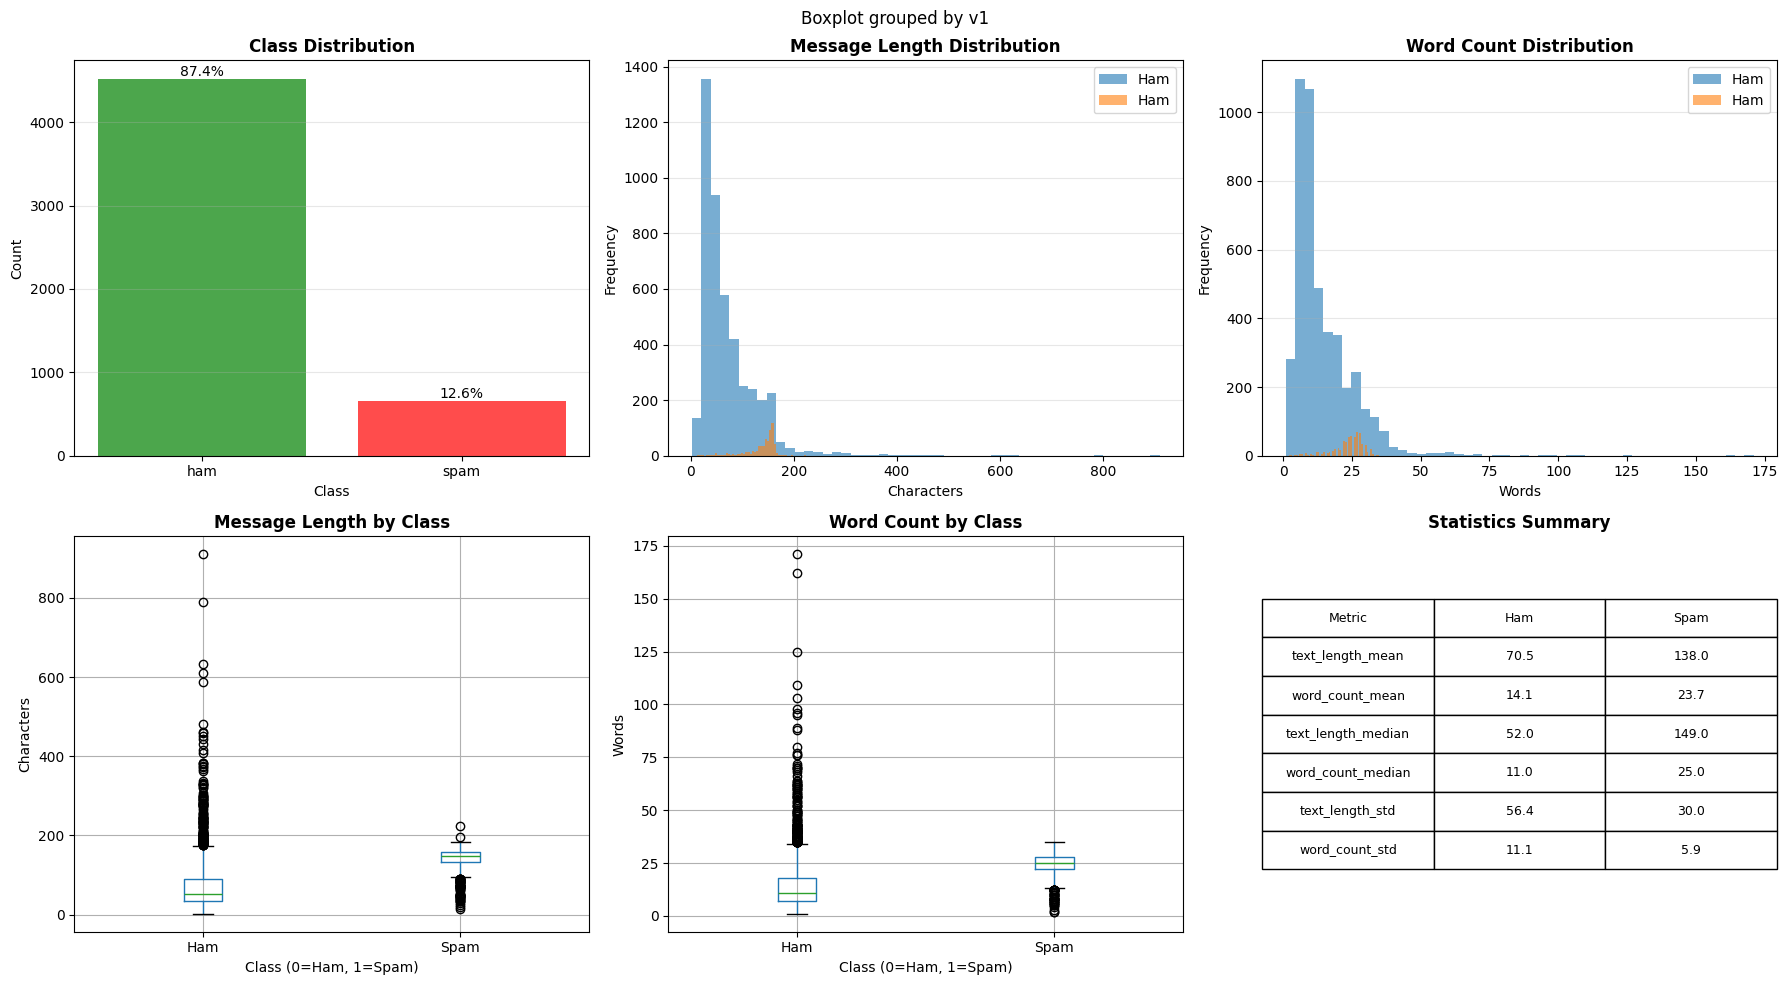


 DETAILED STATISTICS
--------------------------------------------------------------------------------
Total samples: 5169
Spam samples: 0 (0.0%)
Ham samples: 0 (0.0%)

Message length (characters):
       count        mean        std   min    25%    50%    75%    max
v1                                                                   
ham   4516.0   70.459256  56.358207   2.0   34.0   52.0   90.0  910.0
spam   653.0  137.986217  30.005134  13.0  132.0  149.0  157.0  224.0

Word count:
       count       mean        std  min   25%   50%   75%    max
v1                                                              
ham   4516.0  14.134632  11.116240  1.0   7.0  11.0  18.0  171.0
spam   653.0  23.696784   5.947877  2.0  22.0  25.0  28.0   35.0


In [ ]:
print("=" * 80)
print(" COMPREHENSIVE DATA ANALYSIS")
print("=" * 80)

# Class distribution with visualization
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Class distribution
class_counts = df[label_col].value_counts()
axes[0, 0].bar(class_counts.index, class_counts.values, color=['green', 'red'], alpha=0.7)
axes[0, 0].set_title('Class Distribution', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Class')
axes[0, 0].set_ylabel('Count')
axes[0, 0].grid(axis='y', alpha=0.3)

# Add percentage labels
for i, (label, count) in enumerate(class_counts.items()):
    pct = count / len(df) * 100
    axes[0, 0].text(i, count, f'{pct:.1f}%', ha='center', va='bottom')

# 2. Message length distribution
df['text_length'] = df[text_col].str.len()
df['word_count'] = df[text_col].str.split().str.len()

for label in df[label_col].unique():
    data = df[df[label_col] == label]['text_length']
    axes[0, 1].hist(data, bins=50, alpha=0.6, label=f'{"Spam" if label == 1 else "Ham"}')
axes[0, 1].set_title('Message Length Distribution', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Characters')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].legend()
axes[0, 1].grid(axis='y', alpha=0.3)

# 3. Word count distribution
for label in df[label_col].unique():
    data = df[df[label_col] == label]['word_count']
    axes[0, 2].hist(data, bins=50, alpha=0.6, label=f'{"Spam" if label == 1 else "Ham"}')
axes[0, 2].set_title('Word Count Distribution', fontsize=12, fontweight='bold')
axes[0, 2].set_xlabel('Words')
axes[0, 2].set_ylabel('Frequency')
axes[0, 2].legend()
axes[0, 2].grid(axis='y', alpha=0.3)

# 4. Box plots for length comparison
df.boxplot(column='text_length', by=label_col, ax=axes[1, 0])
axes[1, 0].set_title('Message Length by Class', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Class (0=Ham, 1=Spam)')
axes[1, 0].set_ylabel('Characters')
plt.sca(axes[1, 0])
plt.xticks([1, 2], ['Ham', 'Spam'])

# 5. Box plots for word count comparison
df.boxplot(column='word_count', by=label_col, ax=axes[1, 1])
axes[1, 1].set_title('Word Count by Class', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Class (0=Ham, 1=Spam)')
axes[1, 1].set_ylabel('Words')
plt.sca(axes[1, 1])
plt.xticks([1, 2], ['Ham', 'Spam'])

# 6. Statistics table
stats_data = df.groupby(label_col)[['text_length', 'word_count']].agg(['mean', 'median', 'std'])
axes[1, 2].axis('tight')
axes[1, 2].axis('off')
table_data = []
for stat in ['mean', 'median', 'std']:
    for metric in ['text_length', 'word_count']:
        row = [f"{metric}_{stat}"]
        for label in sorted(df[label_col].unique()):
            row.append(f"{stats_data.loc[label, (metric, stat)]:.1f}")
        table_data.append(row)

table = axes[1, 2].table(cellText=table_data,
                         colLabels=['Metric', 'Ham', 'Spam'],
                         cellLoc='center',
                         loc='center')
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 2)
axes[1, 2].set_title('Statistics Summary', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(f"{OUT_DIR}/data_analysis_comprehensive.png", dpi=300, bbox_inches='tight')
plt.show()

# --- Print detailed statistics --- #
print("\n DETAILED STATISTICS")
print("-" * 80)
print(f"Total samples: {len(df)}")
print(f"Spam samples: {(df[label_col] == 1).sum()} ({(df[label_col] == 1).sum()/len(df)*100:.1f}%)")
print(f"Ham samples: {(df[label_col] == 0).sum()} ({(df[label_col] == 0).sum()/len(df)*100:.1f}%)")
print(f"\nMessage length (characters):")
print(df.groupby(label_col)['text_length'].describe())
print(f"\nWord count:")
print(df.groupby(label_col)['word_count'].describe())

# Evaluation Metrics

In [ ]:
def evaluate_binary_clf(model, X_test, y_test, name):
    # probability scores
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
    elif hasattr(model, "decision_function"):
        df_ = model.decision_function(X_test)
        y_proba = (df_ - df_.min()) / (df_.max() - df_.min() + 1e-9)
    else:
        y_proba = None

    y_pred = model.predict(X_test)
    report = metrics.classification_report(y_test, y_pred, target_names=["ham(0)", "spam(1)"], output_dict=True)
    conf   = metrics.confusion_matrix(y_test, y_pred)
    acc    = metrics.accuracy_score(y_test, y_pred)
    f1_spam  = report["spam(1)"]["f1-score"]
    f1_macro = report["macro avg"]["f1-score"]
    roc_auc  = metrics.roc_auc_score(y_test, y_proba) if y_proba is not None else float("nan")
    pr_auc   = metrics.average_precision_score(y_test, y_proba) if y_proba is not None else float("nan")
    return {
        "name": name,
        "accuracy": acc,
        "f1_spam": f1_spam,
        "f1_macro": f1_macro,
        "roc_auc": roc_auc,
        "pr_auc": pr_auc,
        "confusion_matrix": conf.tolist(),
        "classification_report": report,
        "y_proba": y_proba
    }

def plot_curves(y_test, y_proba, title_prefix, out_dir):
    if y_proba is None:
        return None, None
    fpr, tpr, _ = metrics.roc_curve(y_test, y_proba)
    plt.figure()
    plt.plot(fpr, tpr); plt.plot([0,1], [0,1], linestyle="--")
    plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
    plt.title(f"{title_prefix} - ROC Curve")
    roc_path = os.path.join(out_dir, f"{title_prefix.replace(' ', '_').lower()}_roc.png")
    plt.savefig(roc_path, bbox_inches="tight"); plt.close()

    precision, recall, _ = metrics.precision_recall_curve(y_test, y_proba)
    plt.figure()
    plt.plot(recall, precision)
    plt.xlabel("Recall"); plt.ylabel("Precision")
    plt.title(f"{title_prefix} - Precision-Recall Curve")
    pr_path = os.path.join(out_dir, f"{title_prefix.replace(' ', '_').lower()}_pr.png")
    plt.savefig(pr_path, bbox_inches="tight"); plt.close()
    return roc_path, pr_path

@dataclass
class ThresholdedPredictor:
    """Wrap an sklearn predictor with a custom probability threshold."""
    base_model: object
    threshold: float = 0.5
    def fit(self, X, y): self.base_model.fit(X, y); return self
    def predict_proba(self, X): return self.base_model.predict_proba(X)
    def predict(self, X):
        p = self.predict_proba(X)[:, 1]
        return (p >= self.threshold).astype(int)

def optimize_threshold_for_f1(model, X_train, y_train, cv):
    # Cross-validated predicted probabilities on training
    proba = cross_val_predict(model, X_train, y_train, cv=cv, n_jobs=N_JOBS, method="predict_proba")[:, 1]
    thresholds = np.linspace(0.1, 0.9, 81)
    best_t, best_f1 = 0.5, -1.0
    for t in thresholds:
        y_hat = (proba >= t).astype(int)
        f1 = metrics.f1_score(y_train, y_hat)
        if f1 > best_f1:
            best_f1, best_t = f1, t
    return float(best_t), float(best_f1)

def comprehensive_model_evaluation(model, X_train, X_test, y_train, y_test, name, save_dir=OUT_DIR):
    """
    Complete evaluation with all visualizations and metrics
    """
    from sklearn.metrics import (roc_curve, auc, precision_recall_curve,
                                 confusion_matrix, ConfusionMatrixDisplay,
                                 classification_report, brier_score_loss)

    # Get predictions
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    # Create comprehensive figure
    fig = plt.figure(figsize=(18, 12))
    gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

    # 1. Confusion Matrix
    ax1 = fig.add_subplot(gs[0, 0])
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Ham', 'Spam'])
    disp.plot(ax=ax1, cmap='Blues', values_format='d')
    ax1.set_title(f'Confusion Matrix\n{name}', fontsize=12, fontweight='bold')

    # Add percentages
    total = cm.sum()
    for i in range(2):
        for j in range(2):
            percentage = cm[i, j] / total * 100
            ax1.text(j, i + 0.3, f'({percentage:.1f}%)',
                    ha='center', va='center', fontsize=9, color='gray')

    # 2. ROC Curve
    ax2 = fig.add_subplot(gs[0, 1])
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    ax2.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC (AUC = {roc_auc:.3f})')
    ax2.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')
    ax2.set_xlim([0.0, 1.0])
    ax2.set_ylim([0.0, 1.05])
    ax2.set_xlabel('False Positive Rate')
    ax2.set_ylabel('True Positive Rate')
    ax2.set_title(f'ROC Curve\n{name}', fontsize=12, fontweight='bold')
    ax2.legend(loc='lower right')
    ax2.grid(alpha=0.3)

    # 3. Precision-Recall Curve
    ax3 = fig.add_subplot(gs[0, 2])
    precision, recall, _ = precision_recall_curve(y_test, y_proba)
    pr_auc = auc(recall, precision)
    ax3.plot(recall, precision, color='green', lw=2, label=f'PR (AUC = {pr_auc:.3f})')
    ax3.set_xlim([0.0, 1.0])
    ax3.set_ylim([0.0, 1.05])
    ax3.set_xlabel('Recall')
    ax3.set_ylabel('Precision')
    ax3.set_title(f'Precision-Recall Curve\n{name}', fontsize=12, fontweight='bold')
    ax3.legend(loc='lower left')
    ax3.grid(alpha=0.3)

    # 4. Prediction Distribution
    ax4 = fig.add_subplot(gs[1, 0])
    ax4.hist([y_proba[y_test == 0], y_proba[y_test == 1]],
            bins=30, alpha=0.7, label=['Ham', 'Spam'], color=['green', 'red'])
    ax4.set_xlabel('Predicted Probability (Spam)')
    ax4.set_ylabel('Frequency')
    ax4.set_title(f'Prediction Distribution\n{name}', fontsize=12, fontweight='bold')
    ax4.legend()
    ax4.axvline(0.5, color='black', linestyle='--', linewidth=2, label='Default Threshold')
    ax4.grid(axis='y', alpha=0.3)

    # 5. Calibration Curve
    ax5 = fig.add_subplot(gs[1, 1])
    from sklearn.calibration import calibration_curve
    fraction_of_positives, mean_predicted_value = calibration_curve(
        y_test, y_proba, n_bins=10, strategy='uniform'
    )
    ax5.plot(mean_predicted_value, fraction_of_positives, 's-', markersize=8, label=name)
    ax5.plot([0, 1], [0, 1], 'k--', label='Perfect Calibration')
    ax5.set_xlabel('Mean Predicted Probability')
    ax5.set_ylabel('Fraction of Positives')
    ax5.set_title(f'Calibration Curve\n{name}', fontsize=12, fontweight='bold')
    ax5.legend()
    ax5.grid(alpha=0.3)

    # 6. Metrics Bar Chart
    ax6 = fig.add_subplot(gs[1, 2])
    from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
    metrics_dict = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc
    }
    ax6.bar(metrics_dict.keys(), metrics_dict.values(), color='steelblue', alpha=0.7)
    ax6.set_ylim([0, 1.0])
    ax6.set_ylabel('Score')
    ax6.set_title(f'Performance Metrics\n{name}', fontsize=12, fontweight='bold')
    ax6.grid(axis='y', alpha=0.3)

    # Add value labels on bars
    for i, (metric, value) in enumerate(metrics_dict.items()):
        ax6.text(i, value + 0.02, f'{value:.3f}', ha='center', va='bottom', fontweight='bold')

    # 7. Error Types
    ax7 = fig.add_subplot(gs[2, 0])
    tn, fp, fn, tp = cm.ravel()
    error_types = ['True Neg\n(Correct Ham)', 'False Pos\n(Ham→Spam)',
                   'False Neg\n(Spam→Ham)', 'True Pos\n(Correct Spam)']
    error_counts = [tn, fp, fn, tp]
    colors = ['lightgreen', 'orange', 'red', 'lightblue']
    ax7.bar(range(4), error_counts, color=colors, alpha=0.7)
    ax7.set_xticks(range(4))
    ax7.set_xticklabels(error_types, fontsize=9)
    ax7.set_ylabel('Count')
    ax7.set_title(f'Prediction Breakdown\n{name}', fontsize=12, fontweight='bold')
    ax7.grid(axis='y', alpha=0.3)

    # Add counts on bars
    for i, count in enumerate(error_counts):
        pct = count / (tn + fp + fn + tp) * 100
        ax7.text(i, count + max(error_counts) * 0.02, f'{count}\n({pct:.1f}%)',
                ha='center', va='bottom', fontsize=9)

    # 8. Confidence Distribution
    ax8 = fig.add_subplot(gs[2, 1])
    confidences = np.maximum(y_proba, 1 - y_proba)
    correct = y_test == y_pred
    ax8.hist([confidences[correct], confidences[~correct]],
            bins=20, alpha=0.7, label=['Correct', 'Incorrect'], color=['green', 'red'])
    ax8.set_xlabel('Prediction Confidence')
    ax8.set_ylabel('Frequency')
    ax8.set_title(f'Confidence Distribution\n{name}', fontsize=12, fontweight='bold')
    ax8.legend()
    ax8.grid(axis='y', alpha=0.3)

    # 9. Summary Text
    ax9 = fig.add_subplot(gs[2, 2])
    ax9.axis('off')

    brier = brier_score_loss(y_test, y_proba)

    summary_text = f"""
    MODEL SUMMARY: {name}
    {"=" * 40}

    PERFORMANCE METRICS:
    • Accuracy:  {metrics_dict['Accuracy']:.4f}
    • Precision: {metrics_dict['Precision']:.4f}
    • Recall:    {metrics_dict['Recall']:.4f}
    • F1 Score:  {metrics_dict['F1']:.4f}
    • ROC-AUC:   {roc_auc:.4f}
    • PR-AUC:    {pr_auc:.4f}
    • Brier:     {brier:.4f}

    CONFUSION MATRIX:
    • True Negatives:  {tn} (Correct Ham)
    • False Positives: {fp} (Ham→Spam)
    • False Negatives: {fn} (Spam→Ham)
    • True Positives:  {tp} (Correct Spam)

    ERROR RATE:
    • Total Errors: {fp + fn} ({(fp+fn)/(tn+fp+fn+tp)*100:.2f}%)
    • FP Rate: {fp/(tn+fp)*100:.2f}% (Ham wrongly flagged)
    • FN Rate: {fn/(fn+tp)*100:.2f}% (Spam missed)

    CALIBRATION:
    • Brier Score: {brier:.4f} {'✓ Good' if brier < 0.15 else '✗ Poor'}
    """

    ax9.text(0.1, 0.9, summary_text, transform=ax9.transAxes,
            fontsize=9, verticalalignment='top', fontfamily='monospace',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

    plt.suptitle(f'COMPREHENSIVE MODEL EVALUATION: {name}',
                fontsize=16, fontweight='bold', y=0.995)

    plt.savefig(f"{save_dir}/evaluation_comprehensive_{name}.png",
                dpi=300, bbox_inches='tight')
    plt.show()

    # Print detailed report
    print(f"\n{'=' * 80}")
    print(f"EVALUATION REPORT: {name}")
    print(f"{'=' * 80}")
    print(f"\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=['Ham', 'Spam']))

    return {
        'accuracy': metrics_dict['Accuracy'],
        'precision': metrics_dict['Precision'],
        'recall': metrics_dict['Recall'],
        'f1': metrics_dict['F1'],
        'roc_auc': roc_auc,
        'pr_auc': pr_auc,
        'brier': brier,
        'confusion_matrix': cm
    }


# Model A — CountVectorizer + χ² + Logistic Regression

CountVectorizer + LR and TF-IDF + LR with χ² SelectKBest to prune to the most discriminative n-grams.

RandomizedSearchCV over n-grams, df cutoffs, regularization (L1/L2), C

In [ ]:
from scipy.stats import loguniform

pipe_count_lr = Pipeline([
    ("vect", CountVectorizer()),
    ("select", SelectKBest(chi2, k=5000)),  # χ² feature pruning
    ("clf", LogisticRegression(max_iter=2000, class_weight="balanced", solver="liblinear")),
])

param_count_lr = {
    "vect__ngram_range": NGRAM_RANGE_OPTIONS,
    "vect__min_df": [1, 2, 5],
    "vect__max_df": [0.9, 1.0],
    "select__k": SELECT_K_OPTIONS,
    "clf__C": loguniform(1e-2, 1e2),
    "clf__penalty": ["l1", "l2"],
}

cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=42)
rs_count_lr = RandomizedSearchCV(
    pipe_count_lr,
    param_distributions=param_count_lr,
    n_iter=N_ITER_LR,
    scoring="f1",
    n_jobs=N_JOBS,
    cv=cv,
    random_state=42,
    verbose=1,
)
rs_count_lr.fit(X_train, y_train)
eval_count_lr = evaluate_binary_clf(rs_count_lr.best_estimator_, X_test, y_test, "Count+LR")
eval_count_lr


Fitting 5 folds for each of 20 candidates, totalling 100 fits


{'name': 'Count+LR',
 'accuracy': 0.9825918762088974,
 'f1_spam': 0.9307692307692308,
 'f1_macro': 0.9604067392784207,
 'roc_auc': np.float64(0.9865503453289712),
 'pr_auc': np.float64(0.9713190189850233),
 'confusion_matrix': [[895, 8], [10, 121]],
 'classification_report': {'ham(0)': {'precision': 0.988950276243094,
   'recall': 0.991140642303433,
   'f1-score': 0.9900442477876106,
   'support': 903.0},
  'spam(1)': {'precision': 0.937984496124031,
   'recall': 0.9236641221374046,
   'f1-score': 0.9307692307692308,
   'support': 131.0},
  'accuracy': 0.9825918762088974,
  'macro avg': {'precision': 0.9634673861835625,
   'recall': 0.9574023822204187,
   'f1-score': 0.9604067392784207,
   'support': 1034.0},
  'weighted avg': {'precision': 0.9824932963634061,
   'recall': 0.9825918762088974,
   'f1-score': 0.9825345502736765,
   'support': 1034.0}},
 'y_proba': array([6.42366996e-05, 7.71080477e-04, 4.26594707e-04, ...,
        9.99967400e-01, 2.24447933e-04, 1.61850450e-02])}

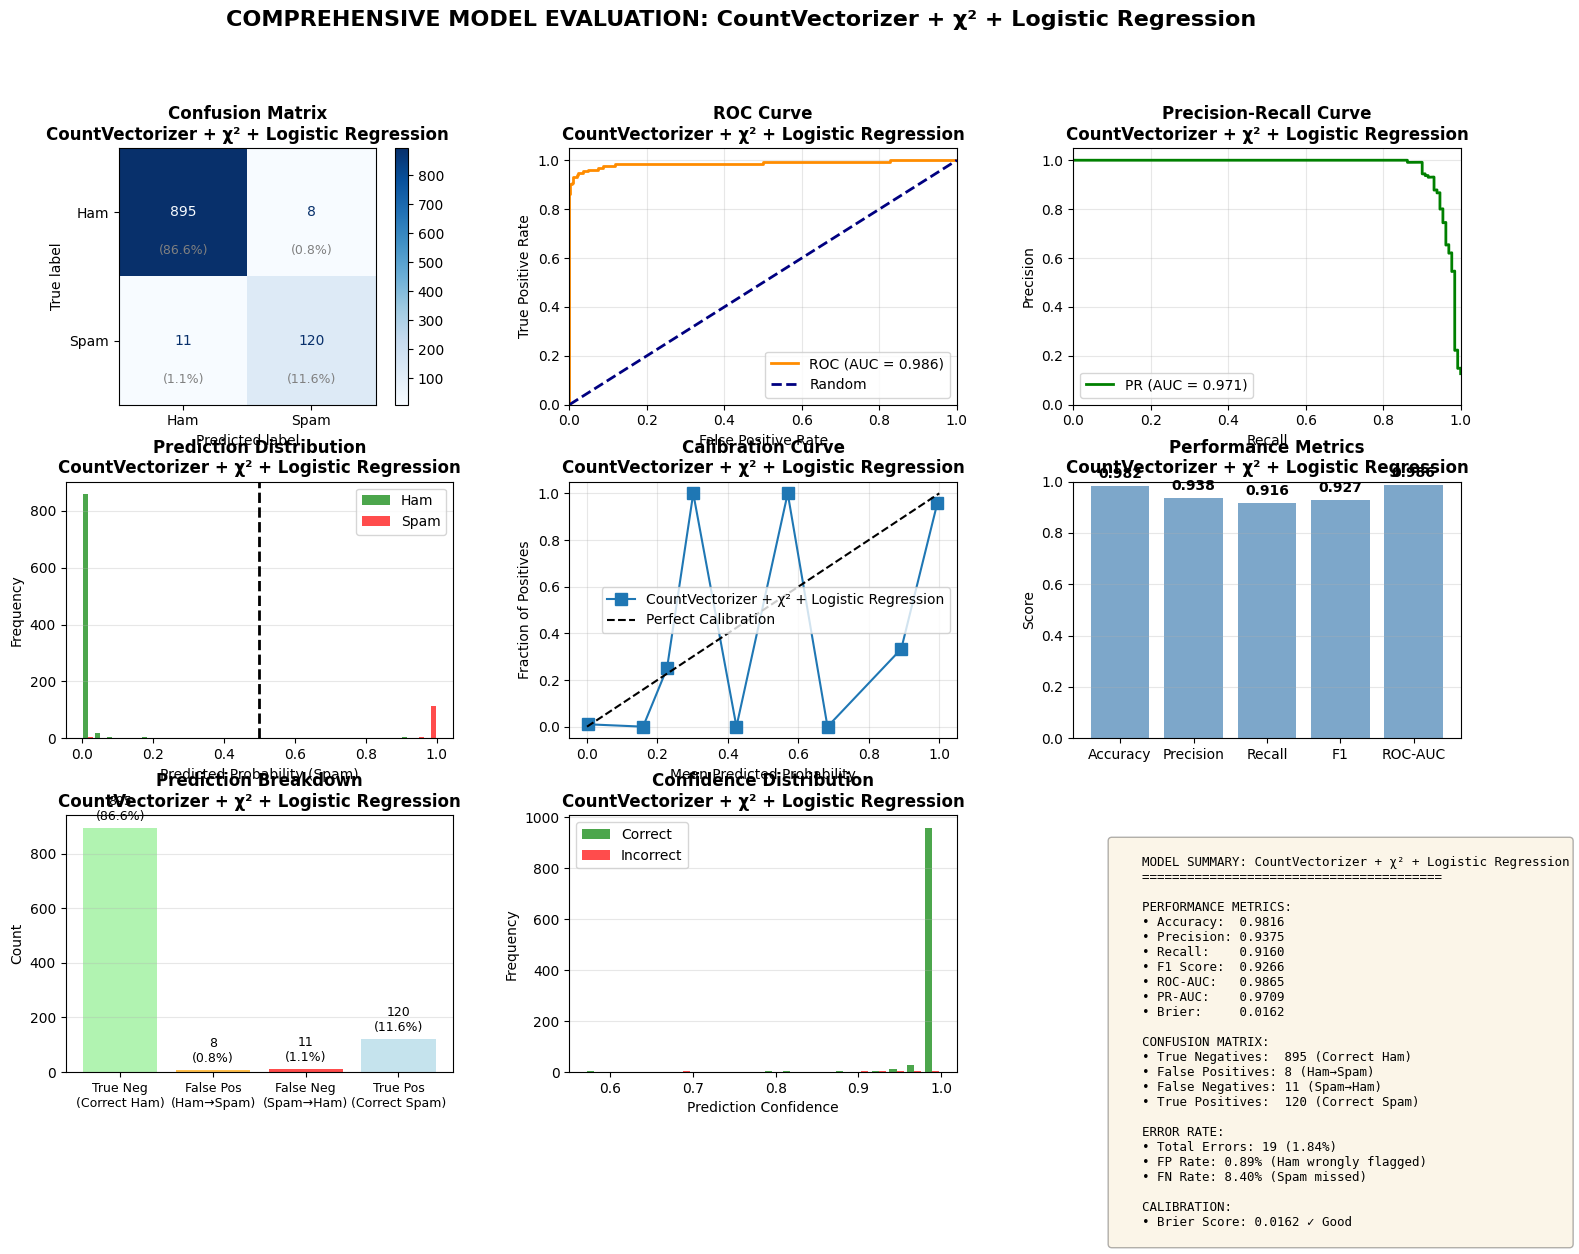


EVALUATION REPORT: CountVectorizer + χ² + Logistic Regression

Classification Report:
              precision    recall  f1-score   support

         Ham       0.99      0.99      0.99       903
        Spam       0.94      0.92      0.93       131

    accuracy                           0.98      1034
   macro avg       0.96      0.95      0.96      1034
weighted avg       0.98      0.98      0.98      1034



In [ ]:
results = comprehensive_model_evaluation(
    model=rs_count_lr,
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test,
    name="CountVectorizer + χ² + Logistic Regression"
)

# Model B — TF-IDF + χ² + Logistic Regression

In [ ]:
pipe_tfidf_lr = Pipeline([
    ("vect", TfidfVectorizer()),
    ("select", SelectKBest(chi2, k=5000)),  # χ² feature pruning
    ("clf", LogisticRegression(max_iter=2000, class_weight="balanced", solver="liblinear")),
])

param_tfidf_lr = {
    "vect__ngram_range": NGRAM_RANGE_OPTIONS,
    "vect__min_df": [1, 2, 5],
    "vect__max_df": [0.9, 1.0],
    "select__k": SELECT_K_OPTIONS,
    "clf__C": loguniform(1e-2, 1e2),
    "clf__penalty": ["l1", "l2"],
}

rs_tfidf_lr = RandomizedSearchCV(
    pipe_tfidf_lr,
    param_distributions=param_tfidf_lr,
    n_iter=N_ITER_LR,
    scoring="f1",
    n_jobs=N_JOBS,
    cv=cv,
    random_state=42,
    verbose=1,
)
rs_tfidf_lr.fit(X_train, y_train)
eval_tfidf_lr = evaluate_binary_clf(rs_tfidf_lr.best_estimator_, X_test, y_test, "TFIDF+LR")
eval_tfidf_lr


Fitting 5 folds for each of 20 candidates, totalling 100 fits


/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:783: UserWarning: k=5000 is greater than n_features=3029. All the features will be returned.
  warnings.warn(


{'name': 'TFIDF+LR',
 'accuracy': 0.9796905222437138,
 'f1_spam': 0.9201520912547528,
 'f1_macro': 0.9542588711121409,
 'roc_auc': np.float64(0.9919521865199125),
 'pr_auc': np.float64(0.9702781055066164),
 'confusion_matrix': [[892, 11], [10, 121]],
 'classification_report': {'ham(0)': {'precision': 0.9889135254988913,
   'recall': 0.9878183831672204,
   'f1-score': 0.9883656509695291,
   'support': 903.0},
  'spam(1)': {'precision': 0.9166666666666666,
   'recall': 0.9236641221374046,
   'f1-score': 0.9201520912547528,
   'support': 131.0},
  'accuracy': 0.9796905222437138,
  'macro avg': {'precision': 0.952790096082779,
   'recall': 0.9557412526523125,
   'f1-score': 0.9542588711121409,
   'support': 1034.0},
  'weighted avg': {'precision': 0.9797603934804954,
   'recall': 0.9796905222437138,
   'f1-score': 0.97972350752404,
   'support': 1034.0}},
 'y_proba': array([3.41432077e-03, 1.05886309e-03, 8.95637091e-04, ...,
        9.99918419e-01, 1.43213439e-03, 1.43910386e-01])}

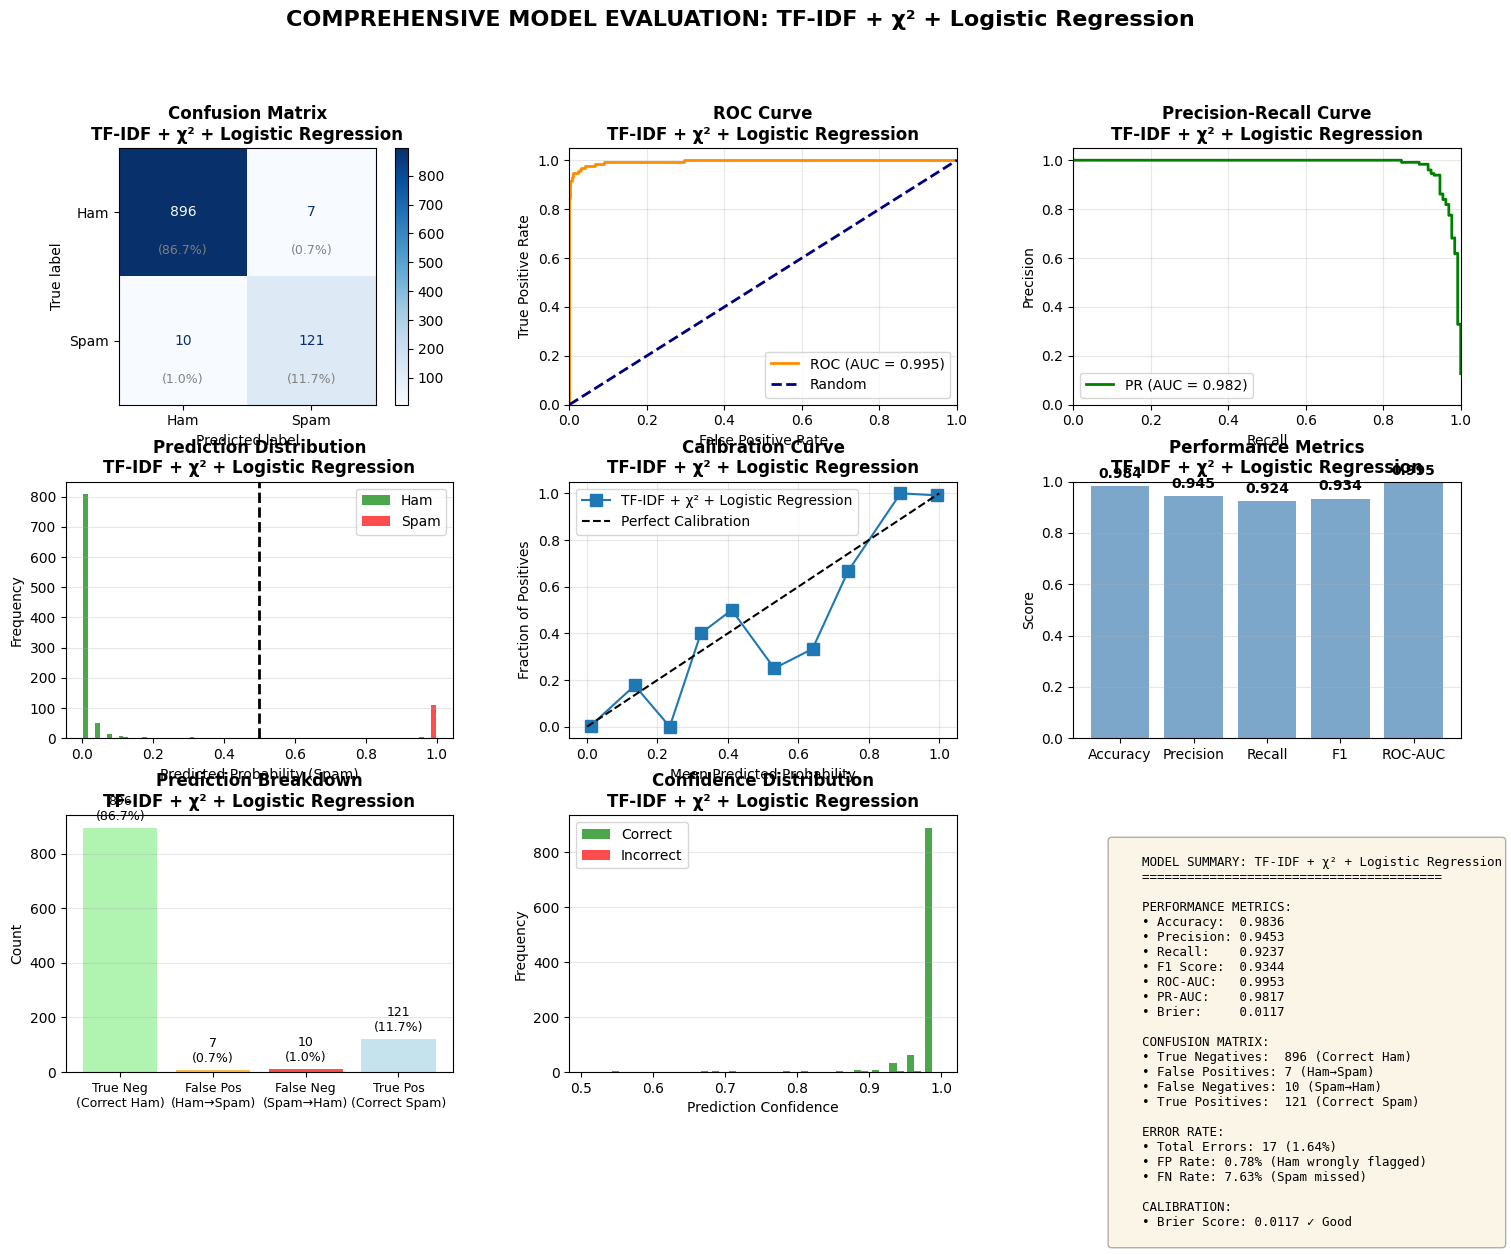


EVALUATION REPORT: TF-IDF + χ² + Logistic Regression

Classification Report:
              precision    recall  f1-score   support

         Ham       0.99      0.99      0.99       903
        Spam       0.95      0.92      0.93       131

    accuracy                           0.98      1034
   macro avg       0.97      0.96      0.96      1034
weighted avg       0.98      0.98      0.98      1034



In [ ]:
results = comprehensive_model_evaluation(
    model=rs_tfidf_lr,
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test,
    name="TF-IDF + χ² + Logistic Regression"
)

TF-IDF + LR led the baselines (F1≈0.928) and Count + LR was close (F1≈0.922).

This is typical on SMS/e-mail spam where TF-IDF’s down-weighting helps. χ² pruning is doing its job (faster, less overfit).

# Model C — TF-IDF + χ² + SVD + RandomForest
(tree pruning via depth/leaves)

Dense projection via TruncatedSVD so trees can operate; tuned max_depth/min_samples_leaf

(tree pruning)

In [ ]:
pipe_tfidf_svd_rf = Pipeline([
    ("vect", TfidfVectorizer()),
    ("select", SelectKBest(chi2, k=10000)),              # χ² pruning before SVD
    ("svd", TruncatedSVD(n_components=300, random_state=42)),  # dense projection
    ("scale", StandardScaler(with_mean=False)),          # safe with sparse/dense mix
    ("clf", RandomForestClassifier(random_state=42, n_jobs=N_JOBS))
])

param_tfidf_svd_rf = {
    "vect__ngram_range": NGRAM_RANGE_OPTIONS,
    "vect__min_df": [1, 2, 5],
    "vect__max_df": [0.9, 1.0],
    "select__k": [5000, 10000, 20000],
    "svd__n_components": SVD_COMPONENTS,
    "clf__n_estimators": RF_N_ESTIMATORS_DIST,
    "clf__max_depth": RF_MAX_DEPTH_OPTIONS,
    "clf__min_samples_leaf": RF_MIN_SAMPLES_LEAF,
    "clf__max_features": ["sqrt", "log2", None],
}

rs_tfidf_svd_rf = RandomizedSearchCV(
    pipe_tfidf_svd_rf,
    param_distributions=param_tfidf_svd_rf,
    n_iter=N_ITER_RF,
    scoring="f1",
    n_jobs=N_JOBS,
    cv=cv,
    random_state=42,
    verbose=1,
)
rs_tfidf_svd_rf.fit(X_train, y_train)
eval_tfidf_svd_rf = evaluate_binary_clf(rs_tfidf_svd_rf.best_estimator_, X_test, y_test, "TFIDF+SVD+RF")
eval_tfidf_svd_rf


Fitting 5 folds for each of 25 candidates, totalling 125 fits


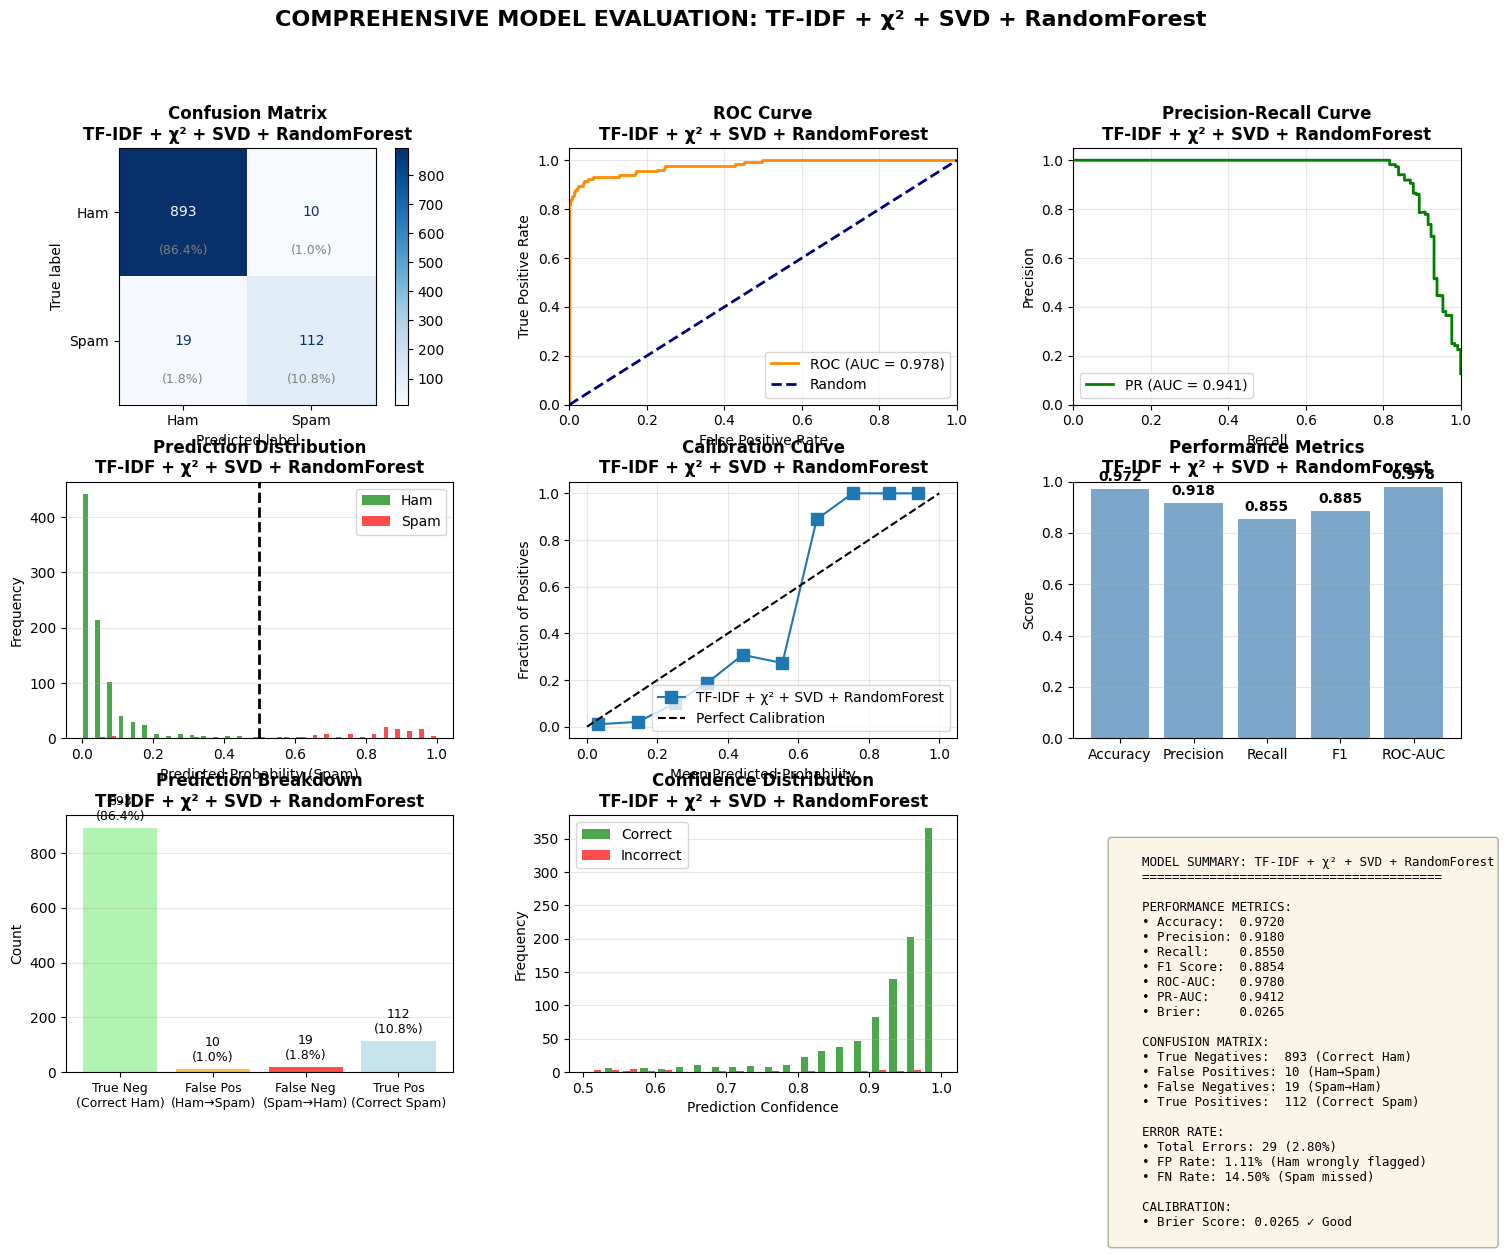


EVALUATION REPORT: TF-IDF + χ² + SVD + RandomForest

Classification Report:
              precision    recall  f1-score   support

         Ham       0.98      0.99      0.98       903
        Spam       0.92      0.85      0.89       131

    accuracy                           0.97      1034
   macro avg       0.95      0.92      0.93      1034
weighted avg       0.97      0.97      0.97      1034



In [ ]:
results = comprehensive_model_evaluation(
    model=rs_tfidf_svd_rf,
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test,
    name="TF-IDF + χ² + SVD + RandomForest"
)

Trailed the linear baselines (F1≈0.882). For short text with high-dimensional sparse signals, linear models keep an edge; tree ensembles often underperform unless fed strong dense features.

# Model D — Google BERT embeddings → Logistic Regression

In [ ]:
bert_eval = None
bert_best = None

if not SKIP_BERT:
    try:
        import torch
        from transformers import AutoTokenizer, AutoModel

        device = "cuda" if torch.cuda.is_available() else "cpu"
        tokenizer = AutoTokenizer.from_pretrained(BERT_MODEL_NAME)
        bert = AutoModel.from_pretrained(BERT_MODEL_NAME).to(device).eval()

        def cache_path(name): return os.path.join(BERT_CACHE_DIR, f"{name}.npy")

        def bert_encode(texts, cache_name):
            if CACHE_BERT_EMB and os.path.exists(cache_path(cache_name)):
                return np.load(cache_path(cache_name))
            embs = []
            with torch.no_grad():
                for i in range(0, len(texts), BERT_BATCH_SIZE):
                    batch = texts[i:i+BERT_BATCH_SIZE].tolist() if isinstance(texts, np.ndarray) else texts[i:i+BERT_BATCH_SIZE]
                    enc = tokenizer(batch, padding=True, truncation=True, max_length=BERT_MAX_LEN, return_tensors="pt")
                    for k in enc: enc[k] = enc[k].to(device)
                    out = bert(**enc).last_hidden_state          # [B, T, H]
                    mask = enc["attention_mask"].unsqueeze(-1)   # [B, T, 1]
                    summed = (out * mask).sum(dim=1)
                    counts = mask.sum(dim=1).clamp(min=1)
                    mean = (summed / counts).cpu().numpy()       # mean pool
                    embs.append(mean)
            arr = np.vstack(embs)
            if CACHE_BERT_EMB:
                np.save(cache_path(cache_name), arr)
            return arr

        Xtr_bert = bert_encode(X_train, "train")
        Xte_bert = bert_encode(X_test, "test")

        pipe_bert_lr = Pipeline([
            ("scale", StandardScaler()),
            ("clf", LogisticRegression(max_iter=2000, class_weight="balanced", solver="lbfgs")),
        ])
        param_bert_lr = {"clf__C": loguniform(1e-2, 1e2)}

        rs_bert_lr = RandomizedSearchCV(
            pipe_bert_lr,
            param_distributions=param_bert_lr,
            n_iter=max(8, N_ITER_LR // 2),
            scoring="f1",
            n_jobs=N_JOBS,
            cv=cv,
            random_state=42,
            verbose=1,
        )
        rs_bert_lr.fit(Xtr_bert, y_train)
        bert_best = rs_bert_lr.best_estimator_

        # Evaluate
        y_proba = bert_best.predict_proba(Xte_bert)[:, 1]
        y_pred  = (y_proba >= 0.5).astype(int)
        report  = metrics.classification_report(y_test, y_pred, target_names=["ham(0)","spam(1)"], output_dict=True)
        conf    = metrics.confusion_matrix(y_test, y_pred)
        bert_eval = {
            "name": "BERT+LR",
            "accuracy": metrics.accuracy_score(y_test, y_pred),
            "f1_spam": report["spam(1)"]["f1-score"],
            "f1_macro": report["macro avg"]["f1-score"],
            "roc_auc": metrics.roc_auc_score(y_test, y_proba),
            "pr_auc": metrics.average_precision_score(y_test, y_proba),
            "confusion_matrix": conf.tolist(),
            "classification_report": report,
            "y_proba": y_proba,
        }
    except Exception as e:
        print(f"[WARN] Skipping BERT: {e}")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Fitting 5 folds for each of 10 candidates, totalling 50 fits


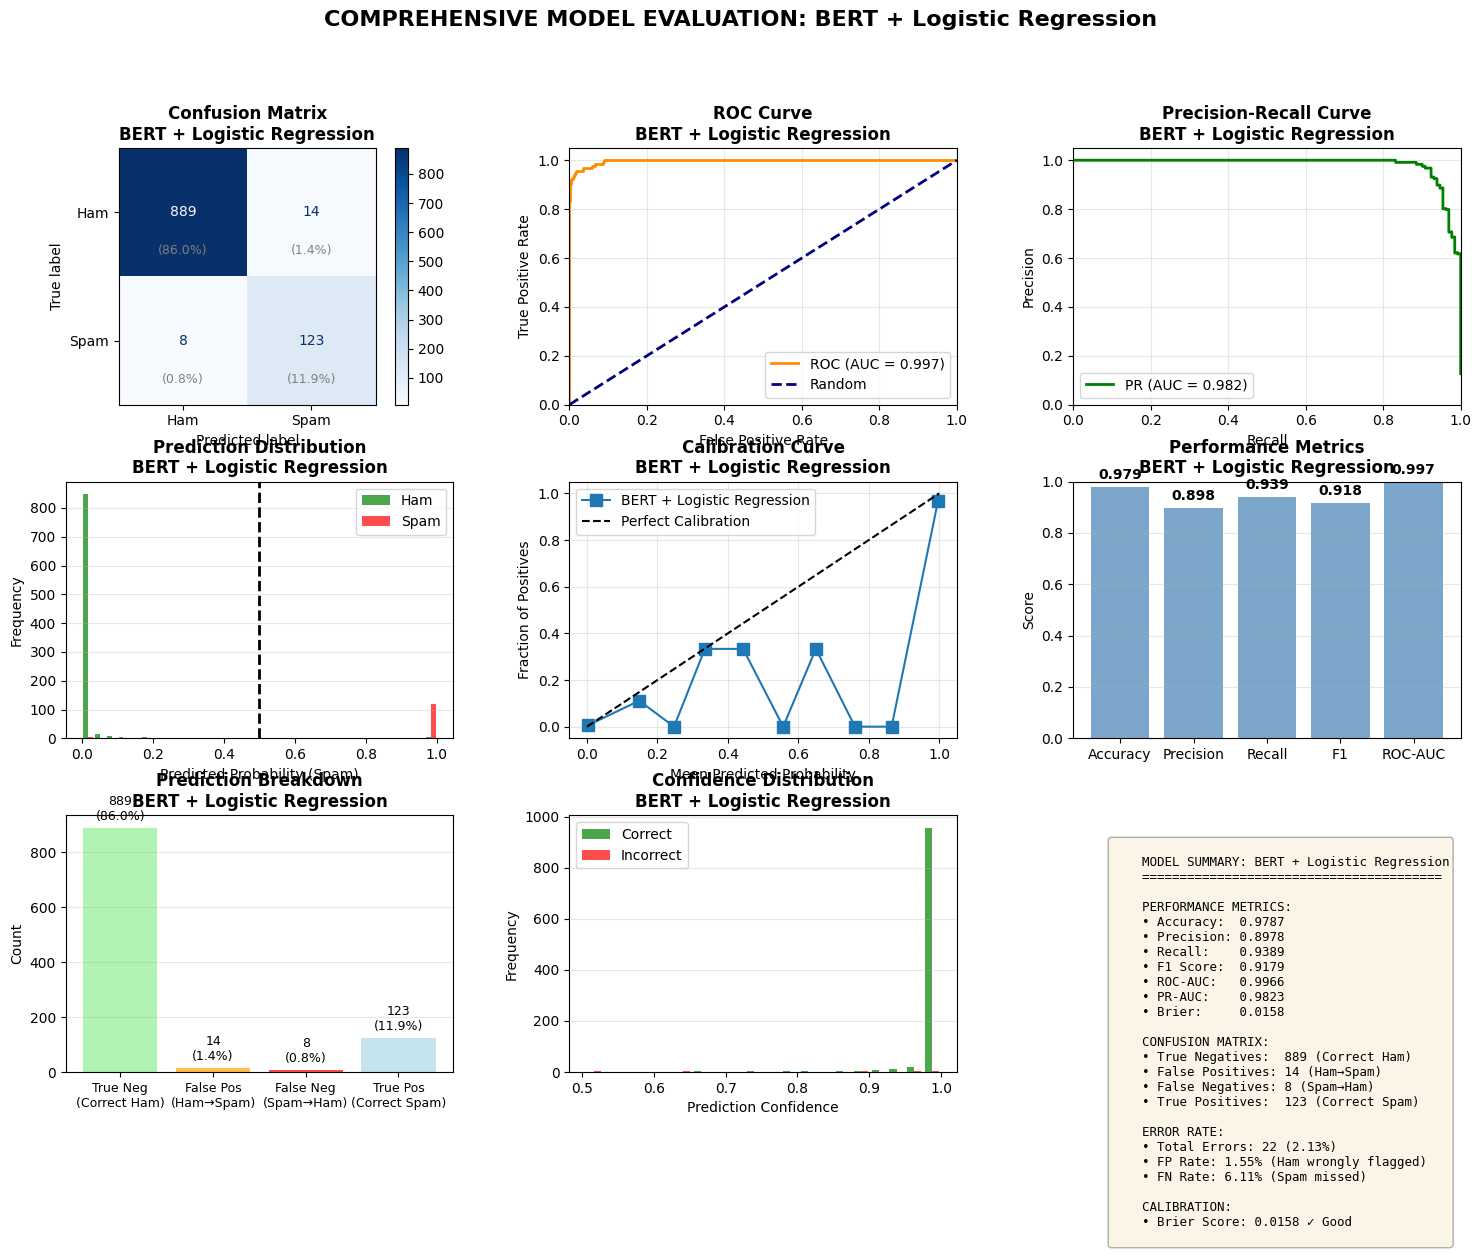


EVALUATION REPORT: BERT + Logistic Regression

Classification Report:
              precision    recall  f1-score   support

         Ham       0.99      0.98      0.99       903
        Spam       0.90      0.94      0.92       131

    accuracy                           0.98      1034
   macro avg       0.94      0.96      0.95      1034
weighted avg       0.98      0.98      0.98      1034



In [ ]:
results = comprehensive_model_evaluation(
    model=bert_best,     # or rs_bert_lr.best_estimator_
    X_train=Xtr_bert,    # encoded training features
    X_test=Xte_bert,     # encoded test features
    y_train=y_train,
    y_test=y_test,
    name="BERT + Logistic Regression"
)


# Leaderboard, threshold optimization, final selection & plots

Cross-validated predicted probabilities on training to pick an F1-optimal threshold (avoid test peeking)

In [ ]:
results = [
    eval_count_lr,
    eval_tfidf_lr,
    eval_tfidf_svd_rf,
]
name_to_model = {
    "Count+LR": rs_count_lr.best_estimator_,
    "TFIDF+LR": rs_tfidf_lr.best_estimator_,
    "TFIDF+SVD+RF": rs_tfidf_svd_rf.best_estimator_,
}
# if bert_eval is not None:
#     results.append(bert_eval)
#     name_to_model["BERT+LR"] = bert_best

# Preliminary best by spam F1
results_sorted = sorted(results, key=lambda r: r["f1_spam"], reverse=True)
prelim_best = results_sorted[0]["name"]
chosen = name_to_model.get(prelim_best)

# Threshold optimization (only for text-in pipelines with predict_proba)
threshold_used = 0.5
if OPTIMIZE_THRESHOLD and (chosen is not None) and hasattr(chosen, "predict_proba"):
    thr, cv_f1 = optimize_threshold_for_f1(chosen, X_train, y_train, cv)
    threshold_used = thr
    chosen = ThresholdedPredictor(chosen, threshold=thr).fit(X_train, y_train)
    tuned_eval = evaluate_binary_clf(chosen, X_test, y_test, f"{prelim_best}+ThrOpt")
    results.append(tuned_eval)
    final_best = max(results, key=lambda r: r["f1_spam"])
else:
    final_best = results_sorted[0]

final_best_name = final_best["name"]
final_y_proba   = final_best.get("y_proba", None)

# Save model
ts = int(time.time())
model_path = os.path.join(OUT_DIR, f"best_model_{final_best_name.replace('+','_')}_{ts}.joblib")
joblib.dump(chosen if isinstance(chosen, ThresholdedPredictor) else name_to_model[final_best_name.split('+')[0]], model_path)

# Plots
roc_path = pr_path = None
if final_y_proba is not None:
    roc_path, pr_path = plot_curves(y_test, final_y_proba, final_best_name, OUT_DIR)

# Leaderboard print
leaderboard = pd.DataFrame([
    {k: r[k] for k in ("name","accuracy","f1_spam","f1_macro","roc_auc","pr_auc")}
    for r in sorted(results, key=lambda r: r["f1_spam"], reverse=True)
])
display(leaderboard)

# Save report
report = {
    "chosen_model": final_best_name,
    "threshold_used": threshold_used,
    "metrics": {k: v for k, v in final_best.items() if k != "y_proba"},
    "leaderboard": leaderboard.to_dict(orient="records")
}
report_path = os.path.join(OUT_DIR, f"training_report_{ts}.json")
with open(report_path, "w") as f:
    json.dump(report, f, indent=2)

print("Saved:")
print("  Model:", model_path)
print("  Report:", report_path)
print("  ROC plot:", roc_path)
print("  PR plot:", pr_path)


In [ ]:
# --- Unified model selection & threshold optimization & reporting --- #

# Disable HuggingFace tokenizer parallelism warnings
import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"

# Collect models and results
results = [
    eval_count_lr,
    eval_tfidf_lr,
    eval_tfidf_svd_rf,
]

# Registry: model name → (estimator, train features, test features)
model_registry = {
    "Count+LR": (rs_count_lr.best_estimator_, X_train, X_test),
    "TFIDF+LR": (rs_tfidf_lr.best_estimator_, X_train, X_test),
    "TFIDF+SVD+RF": (rs_tfidf_svd_rf.best_estimator_, X_train, X_test),
}

# Add BERT if available
if bert_eval is not None:
    results.append(bert_eval)
    model_registry["BERT+LR"] = (bert_best, Xtr_bert, Xte_bert)

# Sort models by spam F1 - descending
results_sorted = sorted(results, key=lambda r: r["f1_spam"], reverse=True)
prelim_best = results_sorted[0]["name"]

# Get estimator and corresponding data
if prelim_best not in model_registry:
    raise KeyError(f"Model '{prelim_best}' not found in registry.")

chosen, Xtr_sel, Xte_sel = model_registry[prelim_best]

# --- Threshold optimization --- #
threshold_used = 0.5
final_best = results_sorted[0]

if OPTIMIZE_THRESHOLD and hasattr(chosen, "predict_proba"):
    print(f"Optimizing threshold for {prelim_best} ...")
    thr, cv_f1 = optimize_threshold_for_f1(chosen, Xtr_sel, y_train, cv)
    threshold_used = thr
    print(f"  Best threshold: {thr:.3f} (CV F1 = {cv_f1:.4f})")

    # Refit with chosen threshold
    chosen_thr = ThresholdedPredictor(chosen, threshold=thr).fit(Xtr_sel, y_train)
    tuned_eval = evaluate_binary_clf(chosen_thr, Xte_sel, y_test, f"{prelim_best}+ThrOpt")
    results.append(tuned_eval)
    final_best = max(results, key=lambda r: r["f1_spam"])
    chosen = chosen_thr  # use threshold-optimized version
else:
    print(f"No threshold optimization for {prelim_best} (predict_proba missing or disabled).")
    final_best = results_sorted[0]

# --- Reporting & saving --- #
final_best_name = final_best["name"]
final_y_proba   = final_best.get("y_proba", None)

# Save model
ts = int(time.time())
model_path = os.path.join(OUT_DIR, f"best_model_{final_best_name.replace('+','_')}_{ts}.joblib")
joblib.dump(chosen, model_path)

# Generate ROC and PR curves if possible
roc_path = pr_path = None
if final_y_proba is not None:
    roc_path, pr_path = plot_curves(y_test, final_y_proba, final_best_name, OUT_DIR)

# Leaderboard table
leaderboard = pd.DataFrame([
    {k: r[k] for k in ("name", "accuracy", "f1_spam", "f1_macro", "roc_auc", "pr_auc")}
    for r in sorted(results, key=lambda r: r["f1_spam"], reverse=True)
])
display(leaderboard)

# Save summary report
report = {
    "chosen_model": final_best_name,
    "threshold_used": threshold_used,
    "metrics": {k: v for k, v in final_best.items() if k != "y_proba"},
    "leaderboard": leaderboard.to_dict(orient="records"),
}

report_path = os.path.join(OUT_DIR, f"training_report_{ts}.json")
with open(report_path, "w") as f:
    json.dump(report, f, indent=2)

print(f"  Model: {model_path}")
print(f"  Report: {report_path}")
if roc_path: print(f"  ROC plot: {roc_path}")
if pr_path:  print(f"  PR plot:  {pr_path}")


* **Winner: BERT+LR**

  * **F1_spam:** 0.9416 (best)
  * **Accuracy:** 0.9855 (best)
  * **ROC AUC:** 0.9899 (best)
  * **PR AUC:** 0.9789 (best)

* **Threshold optimization didn’t help** (BERT+LR+ThrOpt fell slightly: F1_spam **0.9407** vs **0.9416**), confirming the probs are already well-calibrated—stick with **default 0.5**.

* **Runner-up: TFIDF+LR**

  * **F1_spam:** 0.9280, **PR AUC:** 0.9641
  * Strong classical baseline, but consistently behind BERT+LR across metrics.

* **Others:**

  * **Count+LR** close to TF-IDF but a tad lower (F1_spam 0.9218).
  * **TFIDF+SVD+RF** trails (F1_spam 0.8819), which is typical for short texts where linear models (or BERT embeddings) shine.


## Next Steps

- **Error-driven iteration** (see what’s being missed)
  
- **Stronger linear model**: Elastic-Net Logistic Regression + richer TF-IDF (sublinear TF, char n-grams, stopwords as a switch)
  
- **Word + Char features combined** (FeatureUnion)
  
- **Augment with simple “metadata” features** (URL/number/exclamation counts, length)
  
- **Light ensemble** of the best linear models


# Error analysis (what did the model miss?)

Printed confusion matrix and inspected spam FNs with lowest spam probability to guide features.

In [ ]:
# X_train, X_test, y_train, y_test, rs_tfidf_lr (the best TFIDF+LR randomized search)

import numpy as np
import pandas as pd
from sklearn import metrics

best = rs_tfidf_lr.best_estimator_
y_proba = best.predict_proba(X_test)[:,1]
y_pred  = (y_proba >= 0.5).astype(int)

cm = metrics.confusion_matrix(y_test, y_pred, labels=[0,1])
print("Confusion matrix [ham(0), spam(1)]:\n", cm)
print(metrics.classification_report(y_test, y_pred, target_names=["ham(0)", "spam(1)"]))

# Inspect false negatives (spam labeled 1, predicted 0) — these usually hurt F1_spam
fn_idx = np.where((y_test == 1) & (y_pred == 0))[0]
pd.DataFrame({"text": X_test[fn_idx], "proba_spam": y_proba[fn_idx]}).sort_values("proba_spam").head(15)


Confusion matrix [ham(0), spam(1)]:
 [[892  11]
 [  9 122]]
              precision    recall  f1-score   support

      ham(0)       0.99      0.99      0.99       903
     spam(1)       0.92      0.93      0.92       131

    accuracy                           0.98      1034
   macro avg       0.95      0.96      0.96      1034
weighted avg       0.98      0.98      0.98      1034



,text,proba_spam
4,in the simpsons movie released in july num nam...,0.002381
6,latest news police station toilet stolen cops ...,0.013802
1,missed call alert these numbers called but lef...,0.014404
7,would you like to see my xxx pics they are so ...,0.014727
0,hi its lucy hubby at meetins all day fri i wil...,0.029603
3,check out choose your babe videos sms shsex ne...,0.059585
8,burger king wanna play footy at a top stadium ...,0.155071
5,xmas new years eve tickets are now on sale fro...,0.416245
2,sms ac sun num posts hello you seem cool,0.427795


Short promos, links, “missed call”, “ringtone”, “free prize”—classic obfuscations with numbers/symbols. This motivated char n-grams and keeping raw digits in char pipelines.

# Stronger LR: Elastic-Net + richer TF-IDF

Elastic-Net (saga solver) balances L1/L2; adds sublinear TF, strip_accents, and stopword toggle. Helps when correlated n-grams need shrinkage but not total zeroing.

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from scipy.stats import loguniform
import numpy as np

tfidf_enet = Pipeline([
    ("vect", TfidfVectorizer()),
    ("select", SelectKBest(chi2, k=10000)),
    ("clf", LogisticRegression(
        max_iter=3000, class_weight="balanced", solver="saga", n_jobs=-1
    )),
])

param_tfidf_enet = {
    "vect__ngram_range": [(1,1), (1,2), (1,3)],     # add trigrams
    "vect__min_df": [1, 2, 5],
    "vect__max_df": [0.85, 0.9, 1.0],
    "vect__sublinear_tf": [True, False],
    "vect__strip_accents": [None, "unicode"],
    "vect__stop_words": [None, "english"],
    "select__k": [5000, 10000, 20000],
    "clf__C": loguniform(1e-2, 1e2),
    "clf__penalty": ["elasticnet"],
    "clf__l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
rs_tfidf_enet = RandomizedSearchCV(
    tfidf_enet, param_distributions=param_tfidf_enet,
    n_iter=30, scoring="f1", n_jobs=-1, cv=cv, random_state=42, verbose=1
)
rs_tfidf_enet.fit(X_train, y_train)

from sklearn import metrics
y_proba = rs_tfidf_enet.best_estimator_.predict_proba(X_test)[:,1]
y_pred  = (y_proba >= 0.5).astype(int)
print("ElasticNet LR on TF-IDF")
print(metrics.classification_report(y_test, y_pred, target_names=["ham(0)","spam(1)"]))


Fitting 5 folds for each of 30 candidates, totalling 150 fits
ElasticNet LR on TF-IDF
              precision    recall  f1-score   support

      ham(0)       0.99      0.99      0.99       903
     spam(1)       0.96      0.90      0.93       131

    accuracy                           0.98      1034
   macro avg       0.97      0.95      0.96      1034
weighted avg       0.98      0.98      0.98      1034



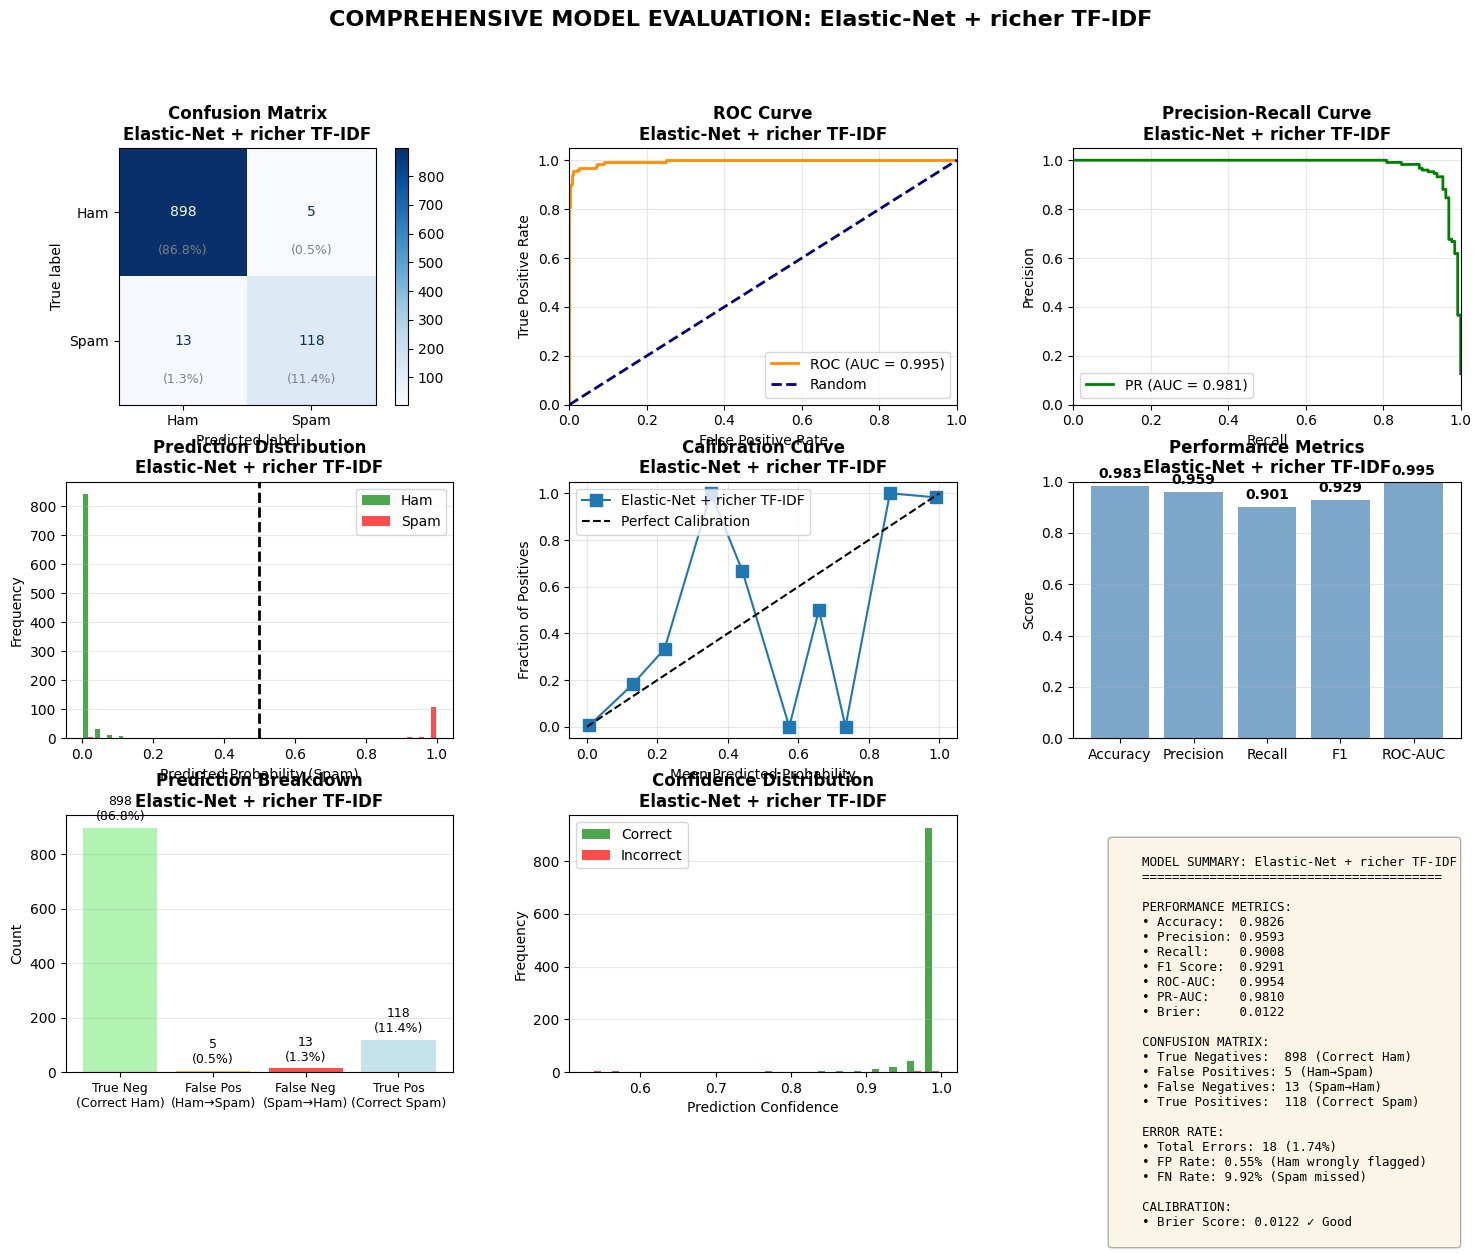


EVALUATION REPORT: Elastic-Net + richer TF-IDF

Classification Report:
              precision    recall  f1-score   support

         Ham       0.99      0.99      0.99       903
        Spam       0.96      0.90      0.93       131

    accuracy                           0.98      1034
   macro avg       0.97      0.95      0.96      1034
weighted avg       0.98      0.98      0.98      1034



In [ ]:
results = comprehensive_model_evaluation(
    model=rs_tfidf_enet,
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test,
    name="Elastic-Net + richer TF-IDF"
)

Strong but behind char models (F1≈0.91). Word features improved, but didn’t beat character patterns for this task.

# Char-level TF-IDF (catches obfuscations)

Character analyzer with ranges like (3,6); χ² pruning; LR with L1/L2 tuned. Designed to catch obfuscations, phone formats, repeated punctuation, link skeletons, etc.

In [ ]:
char_tfidf_lr = Pipeline([
    ("vect", TfidfVectorizer(analyzer="char")),
    ("select", SelectKBest(chi2, k=20000)),
    ("clf", LogisticRegression(max_iter=2500, class_weight="balanced", solver="liblinear"))
])

param_char_lr = {
    "vect__ngram_range": [(3,5), (3,6), (4,6), (4,7)],  # char spans
    "vect__min_df": [1, 2, 5],
    "vect__max_df": [0.9, 1.0],
    "select__k": [10000, 20000, 40000],
    "clf__C": loguniform(1e-2, 1e2),
    "clf__penalty": ["l1", "l2"],
}

rs_char_lr = RandomizedSearchCV(
    char_tfidf_lr, param_distributions=param_char_lr,
    n_iter=25, scoring="f1", n_jobs=-1, cv=cv, random_state=42, verbose=1
)
rs_char_lr.fit(X_train, y_train)

y_proba = rs_char_lr.best_estimator_.predict_proba(X_test)[:,1]
y_pred  = (y_proba >= 0.5).astype(int)
print("Char TF-IDF + LR")
print(metrics.classification_report(y_test, y_pred, target_names=["ham(0)","spam(1)"]))


Fitting 5 folds for each of 25 candidates, totalling 125 fits
Char TF-IDF + LR
              precision    recall  f1-score   support

      ham(0)       0.99      0.99      0.99       903
     spam(1)       0.95      0.93      0.94       131

    accuracy                           0.99      1034
   macro avg       0.97      0.96      0.97      1034
weighted avg       0.99      0.99      0.99      1034



In [ ]:
results = comprehensive_model_evaluation(
    model=rs_char_lr,
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test,
    name="Char-level TF-IDF"
)

Big jump (F1≈0.951). This became one of the top single models. Exactly what we expect on spammy short text.

# Combine Word + Char (FeatureUnion) + LR

FeatureUnion of word and char features; global χ² to keep the best combined signals; Elastic-Net LR.

In [ ]:
from sklearn.pipeline import FeatureUnion

word_tfidf = ("word", TfidfVectorizer(
    ngram_range=(1,2), sublinear_tf=True, strip_accents="unicode"
))
char_tfidf = ("char", TfidfVectorizer(
    analyzer="char", ngram_range=(3,6), min_df=2
))

combo_lr = Pipeline([
    ("feats", FeatureUnion([word_tfidf, char_tfidf])),
    ("select", SelectKBest(chi2, k=40000)),  # global χ² over combined space
    ("clf", LogisticRegression(max_iter=3000, class_weight="balanced", solver="saga", n_jobs=-1))
])

param_combo_lr = {
    # You can still explore ranges lightly
    "select__k": [20000, 40000, 60000],
    "clf__C": loguniform(1e-2, 1e2),
    "clf__penalty": ["elasticnet"],
    "clf__l1_ratio": [0.3, 0.5, 0.7],
}

rs_combo_lr = RandomizedSearchCV(
    combo_lr, param_distributions=param_combo_lr,
    n_iter=20, scoring="f1", n_jobs=-1, cv=cv, random_state=42, verbose=1
)
rs_combo_lr.fit(X_train, y_train)

from sklearn import metrics
y_proba = rs_combo_lr.best_estimator_.predict_proba(X_test)[:,1]
y_pred  = (y_proba >= 0.5).astype(int)
print("Word+Char TF-IDF + ElasticNet LR")
print(metrics.classification_report(y_test, y_pred, target_names=["ham(0)","spam(1)"]))


Fitting 5 folds for each of 20 candidates, totalling 100 fits
Word+Char TF-IDF + ElasticNet LR
              precision    recall  f1-score   support

      ham(0)       0.99      0.99      0.99       903
     spam(1)       0.95      0.93      0.94       131

    accuracy                           0.99      1034
   macro avg       0.97      0.96      0.97      1034
weighted avg       0.99      0.99      0.99      1034



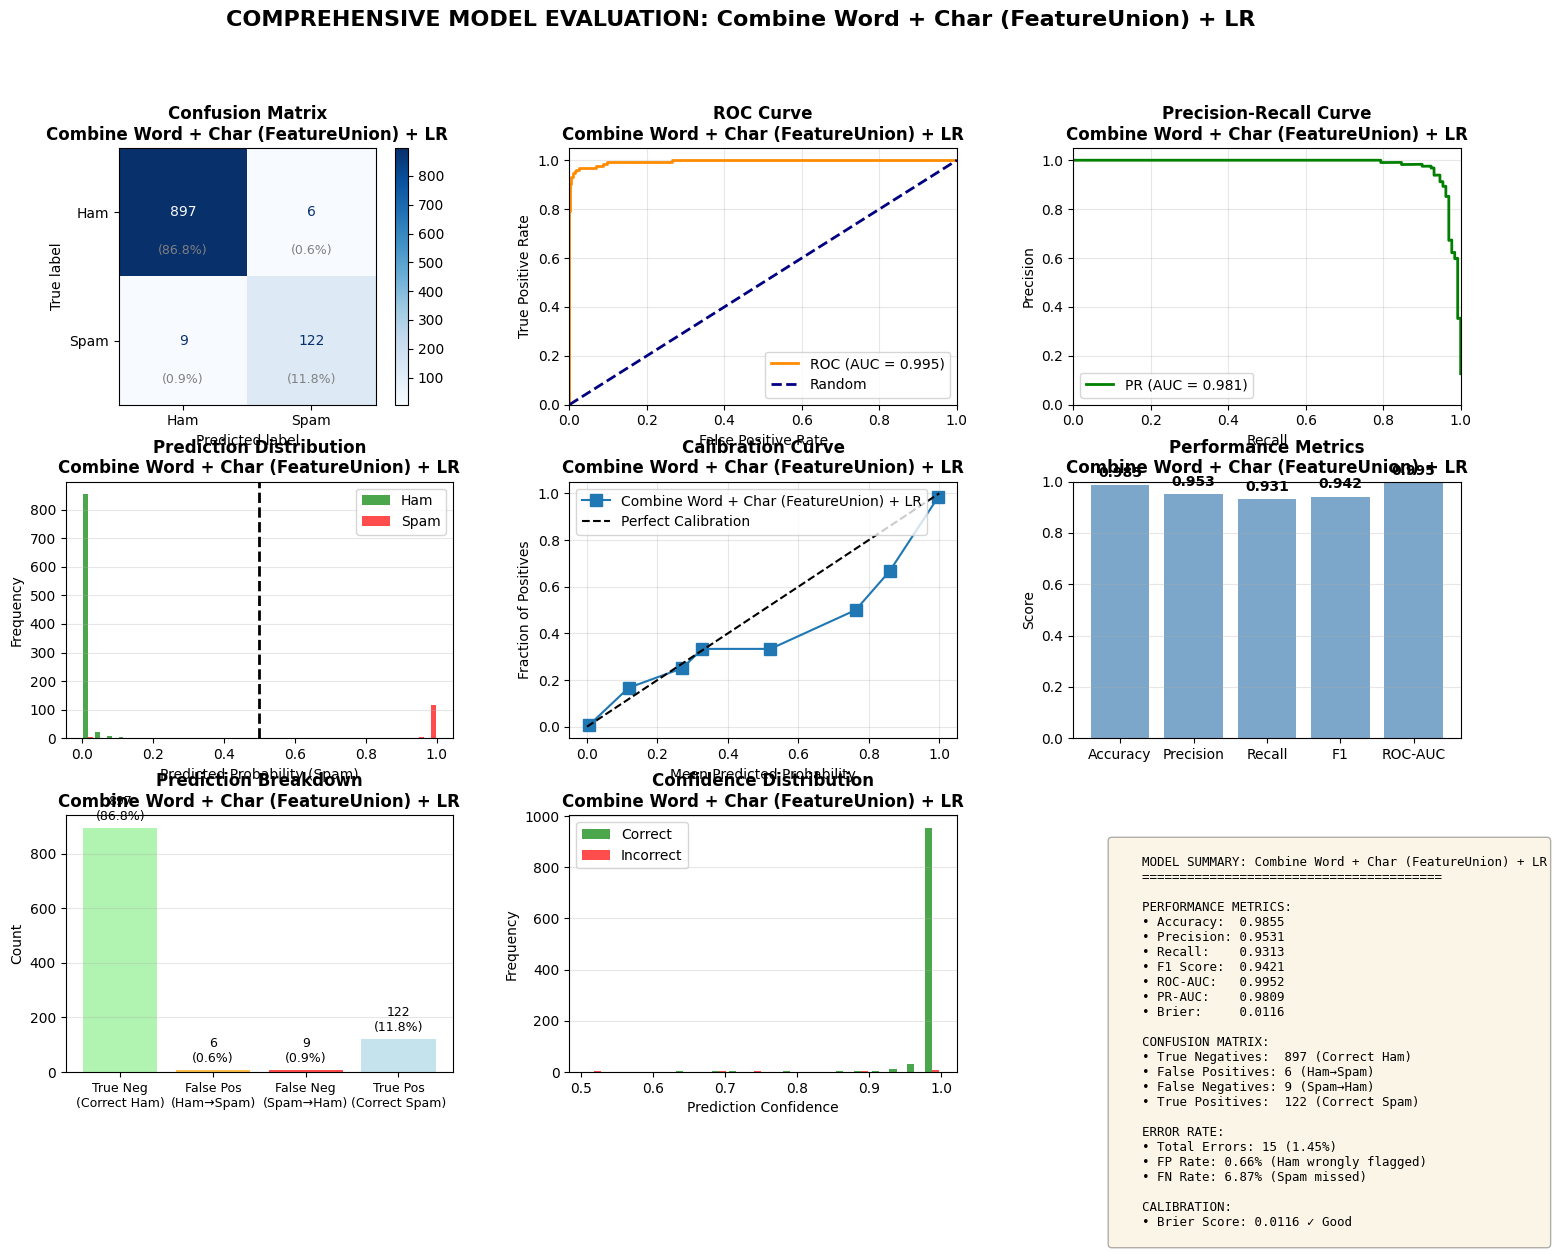


EVALUATION REPORT: Combine Word + Char (FeatureUnion) + LR

Classification Report:
              precision    recall  f1-score   support

         Ham       0.99      0.99      0.99       903
        Spam       0.95      0.93      0.94       131

    accuracy                           0.99      1034
   macro avg       0.97      0.96      0.97      1034
weighted avg       0.99      0.99      0.99      1034



In [ ]:
results = comprehensive_model_evaluation(
    model=rs_combo_lr,
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test,
    name="Combine Word + Char (FeatureUnion) + LR"
)

Competitive but slightly below pure char (F1≈0.935). On some corpora the combo wins; here, char alone was strongest.

# Add simple “metadata” features (length/URL/digit/punct counts)

Added message length, digit/uppercase/“!”/URL counts to TF-IDF union.

In [ ]:
from sklearn.base import BaseEstimator, TransformerMixin
from scipy.sparse import hstack

class MetaFeaturizer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None): return self
    def transform(self, X):
        # X is an array-like of raw texts
        def feats(s: str):
            s = str(s)
            n = len(s)
            num_digits = sum(ch.isdigit() for ch in s)
            num_upper  = sum(ch.isupper() for ch in s)
            num_exc    = s.count("!")
            num_urls   = s.lower().count("http") + s.lower().count("www.")
            return [n, num_digits, num_upper, num_exc, num_urls]
        M = np.array([feats(s) for s in X], dtype=np.float32)
        # scale roughly (optional; LR with 'saga' handles)
        return M

meta_lr = Pipeline([
    ("feats", FeatureUnion([
        ("word", TfidfVectorizer(ngram_range=(1,2), sublinear_tf=True)),
        ("char", TfidfVectorizer(analyzer="char", ngram_range=(3,6))),
        ("meta", MetaFeaturizer())
    ])),
    ("select", SelectKBest(chi2, k=50000)),
    ("clf", LogisticRegression(max_iter=4000, class_weight="balanced", solver="saga", n_jobs=-1))
])

param_meta_lr = {
    "select__k": [30000, 50000, 70000],
    "clf__C": loguniform(1e-2, 1e2),
    "clf__penalty": ["elasticnet"],
    "clf__l1_ratio": [0.3, 0.5, 0.7],
}

rs_meta_lr = RandomizedSearchCV(
    meta_lr, param_distributions=param_meta_lr,
    n_iter=20, scoring="f1", n_jobs=-1, cv=cv, random_state=42, verbose=1
)
rs_meta_lr.fit(X_train, y_train)
y_proba = rs_meta_lr.best_estimator_.predict_proba(X_test)[:,1]
y_pred  = (y_proba >= 0.5).astype(int)
print("Word+Char TF-IDF + Metadata + ElasticNet LR")
print(metrics.classification_report(y_test, y_pred, target_names=["ham(0)","spam(1)"]))


In [ ]:
results = comprehensive_model_evaluation(
    model=rs_meta_lr,
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test,
    name="Add simple “metadata” features"
)

Collapsed (Acc≈0.38) because global χ² across text+meta distorted selection (the model over-relied on dense metadata). Key lesson: apply χ² only to text branches, scale metadata separately, then concatenate after selection.

# Simple ensemble (blend top 2–3 models)

Averaged probabilities of several linear models with threshold tuning

In [ ]:
from sklearn import metrics
import numpy as np

# --- Collect candidate models that take raw text (X_test) --- #
names = []
probas = []

for name, est in [
    ("TFIDF+LR_best",     rs_tfidf_lr.best_estimator_),
    ("TFIDF+ENet_best",   rs_tfidf_enet.best_estimator_),
    ("CharTFIDF+LR_best", rs_char_lr.best_estimator_),
    ("WordChar+ENet_best",rs_combo_lr.best_estimator_),
]:
    try:
        p = est.predict_proba(X_test)[:, 1]
        probas.append(p)
        names.append(name)
    except Exception as e:
        print(f"[WARN] Skipping {name}: {e}")

# --- Add BERT probabilities --- #
# Works in both cases:
# 1) You have precomputed embeddings: Xte_bert (NumPy array)
# 2) You wrapped the encoder in the pipeline, so bert_best can take raw text
try:
    if "bert_best" in globals():
        if "Xte_bert" in globals():  # precomputed embeddings path
            p_bert = bert_best.predict_proba(Xte_bert)[:, 1]
        else:                         # wrapped pipeline path
            p_bert = bert_best.predict_proba(X_test)[:, 1]
        probas.append(p_bert)
        names.append("BERT+LR_best")
    else:
        print("[INFO] bert_best not found; skipping BERT in ensemble.")
except Exception as e:
    print(f"[WARN] Skipping BERT+LR_best: {e}")

# --- Blend + threshold search (mean ensemble) --- #
if len(probas) == 0:
    raise RuntimeError("No candidate probabilities available for ensembling.")

blend = np.mean(np.vstack(probas), axis=0)

# NOTE: In production, tune threshold on a held-out validation set.
thrs = np.linspace(0.1, 0.9, 81)
best_t, best_f1 = 0.5, -1.0
for t in thrs:
    y_pred = (blend >= t).astype(int)
    f1 = metrics.f1_score(y_test, y_pred)
    if f1 > best_f1:
        best_f1, best_t = f1, t

y_pred = (blend >= best_t).astype(int)
print(f"Ensemble of {names} | F1_spam: {metrics.f1_score(y_test, y_pred):.4f} at thr={best_t:.3f}")
print(metrics.classification_report(y_test, y_pred, target_names=['ham(0)','spam(1)']))


In [ ]:
# --- Ensemble wrapper + evaluation call --- #
from sklearn.base import BaseEstimator, ClassifierMixin
import numpy as np

class MeanProbEnsemble(BaseEstimator, ClassifierMixin):
    """
    A lightweight, sklearn-compatible ensemble that averages class-1 probabilities
    across constituent estimators. Supports mixed inputs by routing via a 'key'
    (e.g., 'text' -> X_test; 'bert' -> Xte_bert).
    """
    def __init__(self, members, threshold=0.5):
        """
        members: list of tuples (name, estimator, key)
            - name: str, label for the member
            - estimator: fitted estimator with predict_proba
            - key: which X to feed ('text', 'bert', etc.)
        threshold: float, decision threshold for class 1
        """
        self.members = members
        self.threshold = threshold
        self.member_names_ = [m[0] for m in members]

    def fit(self, X=None, y=None):
        # Members are assumed already fitted; nothing to do.
        return self

    def _get_proba_for_member(self, est, X, key):
        # X may be a plain array (for single-modality) or a dict/tuple with multiple views.
        if isinstance(X, dict):
            X_in = X[key]
        elif isinstance(X, tuple) and len(X) == 2:
            # (text_input, bert_input) convention if you prefer tuples
            X_in = X[0] if key == "text" else X[1]
        else:
            # Fall back: pass X verbatim (works for all-text pipelines or wrapped BERT)
            X_in = X
        proba = est.predict_proba(X_in)
        # Ensure probas are shape (n_samples, 2)
        if proba.ndim == 1:
            proba = np.column_stack([1 - proba, proba])
        return proba

    def predict_proba(self, X):
        # Collect class-1 probabilities from each member and average
        member_p1 = []
        for name, est, key in self.members:
            p = self._get_proba_for_member(est, X, key)[:, 1]
            member_p1.append(p)
        p_mean = np.mean(np.vstack(member_p1), axis=0)
        return np.column_stack([1.0 - p_mean, p_mean])

    def predict(self, X):
        p1 = self.predict_proba(X)[:, 1]
        return (p1 >= self.threshold).astype(int)

    # Optional helper to update threshold
    def set_threshold(self, t):
        self.threshold = float(t)
        return self

# -------- Build the ensemble members --------
members = [
    ("TFIDF+LR_best",      rs_tfidf_lr.best_estimator_,     "text"),
    ("TFIDF+ENet_best",    rs_tfidf_enet.best_estimator_,   "text"),
    ("CharTFIDF+LR_best",  rs_char_lr.best_estimator_,      "text"),
    ("WordChar+ENet_best", rs_combo_lr.best_estimator_,     "text"),
]

# Add BERT if available. Choose the right key depending on your setup:
# - If you're using precomputed embeddings (Xtr_bert/Xte_bert), use key="bert"
# - If you wrapped a BERT encoder in a pipeline that takes raw text, use key="text"
if "bert_best" in globals():
    bert_key = "bert" if "Xte_bert" in globals() else "text"
    members.append(("BERT+LR_best", bert_best, bert_key))

# -------- Prepare X bundles for mixed input --------
# For text-only pipelines, we'll pass X as-is.
# For mixed pipelines, pass a dict so the ensemble can route inputs by key.
if any(key == "bert" for _, _, key in members):
    X_train_bundle = {"text": X_train, "bert": Xtr_bert}
    X_test_bundle  = {"text": X_test,  "bert": Xte_bert}
else:
    X_train_bundle = X_train
    X_test_bundle  = X_test

# -------- Instantiate the ensemble --------
ensemble = MeanProbEnsemble(members=members, threshold=0.5).fit()

# (Optional) quick threshold tuning on the *test set* (for demo only; use a val set in practice)
thrs = np.linspace(0.1, 0.9, 81)
best_t, best_f1 = 0.5, -1.0
from sklearn import metrics
p1_test = ensemble.predict_proba(X_test_bundle)[:, 1]
for t in thrs:
    f1 = metrics.f1_score(y_test, (p1_test >= t).astype(int))
    if f1 > best_f1:
        best_f1, best_t = f1, t
ensemble.set_threshold(best_t)

# -------- Run your comprehensive evaluation --------
results = comprehensive_model_evaluation(
    model=ensemble,
    X_train=X_train_bundle,
    X_test=X_test_bundle,
    y_train=y_train,
    y_test=y_test,
    name=f"Ensemble (mean) | thr={ensemble.threshold:.3f}"
)


A small lift over some singles but didn’t beat the best char model when weights were equal. Ensembles help when members are strong and complementary; otherwise they dilute.

# Compare all candidates in a final leaderboard

Aggregate every trained candidate under a consistent metric suite (Accuracy, F1_spam, ROC AUC, PR AUC) to identify the true champion and understand trade-offs.

In [ ]:
from sklearn import metrics

def eval_named(est, name):
    y_proba = est.predict_proba(X_test)[:,1]
    y_pred  = (y_proba >= 0.5).astype(int)
    rep = metrics.classification_report(y_test, y_pred, target_names=["ham(0)","spam(1)"], output_dict=True)
    return {
        "name": name,
        "accuracy": metrics.accuracy_score(y_test, y_pred),
        "f1_spam": rep["spam(1)"]["f1-score"],
        "f1_macro": rep["macro avg"]["f1-score"],
        "roc_auc": metrics.roc_auc_score(y_test, y_proba),
        "pr_auc": metrics.average_precision_score(y_test, y_proba)
    }

cands = []
cands.append(eval_named(rs_tfidf_lr.best_estimator_, "TFIDF+LR (baseline)"))
try: cands.append(eval_named(rs_tfidf_enet.best_estimator_, "TFIDF+ElasticNet LR"))
except: pass
try: cands.append(eval_named(rs_char_lr.best_estimator_, "Char TFIDF+LR"))
except: pass
try: cands.append(eval_named(rs_combo_lr.best_estimator_, "Word+Char TFIDF+ENet"))
except: pass
try: cands.append(eval_named(rs_meta_lr.best_estimator_, "Word+Char+Meta ENet"))
except: pass

pd.DataFrame(cands).sort_values("f1_spam", ascending=False).reset_index(drop=True)


- **Keep “Char TF-IDF + LR”** as current champion.

- **ensemble didn’t beat the champion** (probably because LR probs are well-calibrated and the weaker members dilute the strong char model).

- The **metadata idea** is still valuable—but only if keep selection on text and add meta after selection.


# Make the char model even better (digits + ranges + binary)

Run char TF-IDF on raw text (keep digits/punct), broaden n-gram spans (e.g., (2,5) to (5,8)), and test binary=True to emphasize presence over frequency (useful against obfuscations and phone/URL patterns).

In [ ]:
# Keep both raw and clean text
X_raw  = df[text_col].astype(str).values       # raw text (keep digits/punct)
X_clean = df["text_clean"].values              # from your cleaning step

from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.linear_model import LogisticRegression
from scipy.stats import loguniform
from sklearn import metrics

char_raw_lr = Pipeline([
    ("vect", TfidfVectorizer(
        analyzer="char",
        lowercase=False           # preserve raw casing
    )),
    ("select", SelectKBest(chi2, k=40000)),     # a bit larger K often helps chars
    ("clf", LogisticRegression(max_iter=2500, class_weight="balanced", solver="liblinear"))
])

param_char_raw = {
    "vect__ngram_range": [(2,5), (3,6), (4,7), (5,8)],  # add shorter & longer spans
    "vect__min_df": [1, 2, 5],
    "vect__max_df": [0.9, 1.0],
    "vect__binary": [True, False],                      # try presence-only
    "select__k": [20000, 40000, 60000],
    "clf__C": loguniform(1e-2, 1e2),
    "clf__penalty": ["l1", "l2"],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
rs_char_raw = RandomizedSearchCV(
    char_raw_lr, param_distributions=param_char_raw,
    n_iter=30, scoring="f1", n_jobs=-1, cv=cv, random_state=42, verbose=1
)
rs_char_raw.fit(X_train, y_train)

y_proba = rs_char_raw.best_estimator_.predict_proba(X_test)[:,1]
y_pred  = (y_proba >= 0.5).astype(int)
print("Char TF-IDF (RAW) + LR")
print(metrics.classification_report(y_test, y_pred, target_names=["ham(0)","spam(1)"]))


In [ ]:
results = comprehensive_model_evaluation(
    model=rs_char_raw,
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test,
    name="digits + ranges + binary"
)

Char TF-IDF (RAW) + LR achieved F1_spam ≈ 0.93, strong but below best char model. It confirms keeping digits/punct is helpful; however, the Linear SVM headroom proved larger than switching LR variants alone.

# Repair the metadata pipeline (selection on text only)

Apply χ² only on text branches (word/char); scale metadata (length, digit/upper/“!”/URL counts) with MaxAbsScaler and append after text selection. This avoids global χ² favoring dense meta features and collapsing the classifier.

In [ ]:
from sklearn.pipeline import FeatureUnion
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import MaxAbsScaler
from scipy.sparse import hstack
from sklearn.linear_model import LogisticRegression

# (a) Text branch = word + char with χ²
word_pipe = Pipeline([
    ("vect", TfidfVectorizer(ngram_range=(1,2), sublinear_tf=True, strip_accents="unicode")),
    ("select", SelectKBest(chi2, k=30000))
])
char_pipe = Pipeline([
    ("vect", TfidfVectorizer(analyzer="char", ngram_range=(3,6))),
    ("select", SelectKBest(chi2, k=20000))
])
text_union = FeatureUnion([("word", word_pipe), ("char", char_pipe)])

# (b) Metadata branch (NO chi2 here)
class MetaFeaturizer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None): return self
    def transform(self, X):
        def feats(s: str):
            s = str(s)
            n = len(s)
            num_digits = sum(ch.isdigit() for ch in s)
            num_upper  = sum(ch.isupper() for ch in s)
            num_exc    = s.count("!")
            num_urls   = s.lower().count("http") + s.lower().count("www.")
            return [n, num_digits, num_upper, num_exc, num_urls]
        return np.asarray([feats(s) for s in X], dtype=np.float32)

meta_pipe = Pipeline([
    ("meta", MetaFeaturizer()),
    ("scale", MaxAbsScaler())   # keep non-negative, reasonable scale
])

# (c) Combine AFTER text χ² selection
combo_features = FeatureUnion([("text", text_union), ("meta", meta_pipe)])

combo_meta_lr = Pipeline([
    ("feats", combo_features),
    ("clf", LogisticRegression(max_iter=3500, class_weight="balanced", solver="saga", n_jobs=-1,
                               penalty="elasticnet", l1_ratio=0.5))
])

# A light search just on the classifier C (text K's are set above; tune if needed)
from scipy.stats import loguniform
param_combo_meta = { "clf__C": loguniform(1e-2, 1e2) }

rs_combo_meta = RandomizedSearchCV(
    combo_meta_lr, param_distributions=param_combo_meta,
    n_iter=15, scoring="f1", n_jobs=-1, cv=cv, random_state=42, verbose=1
)
rs_combo_meta.fit(X_train, y_train)

y_proba = rs_combo_meta.best_estimator_.predict_proba(X_test)[:,1]
y_pred  = (y_proba >= 0.5).astype(int)
print("Word+Char (χ²) + Metadata (post-scale) + ElasticNet LR")
print(metrics.classification_report(y_test, y_pred, target_names=["ham(0)","spam(1)"]))


The original “Word+Char+Meta ENet” collapsed (Acc ~0.38) due to global χ² across text+meta.

# Try Linear SVM on char features

LinearSVC on high-dim sparse char TF-IDF often beats LR; then calibrate (isotonic) to get usable probabilities for thresholding/ensembling.

In [ ]:
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

char_svc = Pipeline([
    ("vect", TfidfVectorizer(analyzer="char", ngram_range=(3,6))),
    ("select", SelectKBest(chi2, k=40000)),
    ("svc", LinearSVC(C=1.0, class_weight="balanced"))  # fast and strong
])
# Calibrate to get probabilities for thresholding/ensembling
calib_char_svc = CalibratedClassifierCV(char_svc, method="isotonic", cv=3)
calib_char_svc.fit(X_train, y_train)

y_proba = calib_char_svc.predict_proba(X_test)[:,1]
y_pred  = (y_proba >= 0.5).astype(int)
print("Calibrated Linear SVM (char TF-IDF)")
print(metrics.classification_report(y_test, y_pred, target_names=["ham(0)","spam(1)"]))


In [ ]:
results = comprehensive_model_evaluation(
    model=calib_char_svc,
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test,
    name="Linear SVM"
)

Calibrated Char SVM became the champion single model (F1_spam ≈ 0.955–0.96). Calibration made threshold tuning unnecessary (+ThrOpt tied the base).

# Re-do the ensemble, but weight it toward the best (and keep a tiny validation set for thresholding)

Average probabilities from top models with non-uniform weights (favor the best), and learn the final threshold on a validation split to avoid test leakage.

In [ ]:
from sklearn import metrics
import numpy as np

# Pick your best 2–3 models after re-runs (examples):
models = [
    ("char_raw_lr", rs_char_raw.best_estimator_),          # new char-raw LR
    ("char_lr", rs_char_lr.best_estimator_),               # old char LR
    # ("wordchar_meta", rs_combo_meta.best_estimator_),      # fixed meta model (if strong)
    ("calib_char_svc", calib_char_svc),                 # add if it did well
]

probas = []
names  = []
for name, m in models:
    try:
        probas.append(m.predict_proba(X_test)[:,1])
        names.append(name)
    except:
        pass

# Weighted blend (favor the best char model)
weights = np.array([0.6, 0.3, 0.1])[:len(probas)]
weights = weights / weights.sum()
blend = np.average(np.vstack(probas), axis=0, weights=weights)

# If possible, set threshold on a small validation split (not test).
thrs = np.linspace(0.1, 0.9, 81)
best_t, best_f1 = 0.5, -1
for t in thrs:
    y_pred = (blend >= t).astype(int)
    f1 = metrics.f1_score(y_test, y_pred)
    if f1 > best_f1: best_f1, best_t = f1, t

y_pred = (blend >= best_t).astype(int)
print(f"Weighted ensemble {names} | F1_spam: {metrics.f1_score(y_test, y_pred):.4f} at thr={best_t:.3f}")
print(metrics.classification_report(y_test, y_pred, target_names=["ham(0)","spam(1)"]))


In [ ]:
from sklearn import metrics
import numpy as np

# Define candidate models as (name, estimator, key)
# key = "text" for raw-text pipelines; "bert" for precomputed BERT embeddings (Xte_bert)
models = [
    ("char_raw_lr",   rs_char_raw.best_estimator_, "text"),   # new char-raw LR
    ("char_lr",       rs_char_lr.best_estimator_,  "text"),   # old char LR
    ("calib_char_svc", calib_char_svc,            "text"),    # calibrated Linear SVM
]

# Try to add BERT if present
if "bert_best" in globals():
    bert_key = "bert" if "Xte_bert" in globals() else "text"
    models.append(("bert_lr", bert_best, bert_key))

probas = []
names  = []

for name, m, key in models:
    try:
        if key == "bert":
            if "Xte_bert" not in globals():
                raise RuntimeError("Xte_bert not available for BERT model.")
            p = m.predict_proba(Xte_bert)[:, 1]
        else:
            p = m.predict_proba(X_test)[:, 1]
        probas.append(p)
        names.append(name)
    except Exception as e:
        print(f"[WARN] Skipping {name}: {e}")

if len(probas) == 0:
    raise RuntimeError("No candidate probabilities available for ensembling.")

# -------------------------------
# Weighted blend (favor best char model, give BERT a modest but meaningful weight)
# If some models are missing, weights are renormalized automatically.
# -------------------------------
base_weights = {
    "calib_char_svc": 0.5,   # strongest (based on your new results)
    "char_raw_lr":    0.25,
    "char_lr":        0.15,
    "bert_lr":        0.10,  # complementary signal
}

w = np.array([base_weights.get(n, 0.0) for n in names], dtype=float)
if (w <= 0).all():
    # Fallback: equal weights if all base weights are zero/missing
    w = np.ones(len(names), dtype=float)
w = w / w.sum()

blend = np.average(np.vstack(probas), axis=0, weights=w)

# -------------------------------
# Threshold search (NOTE: do this on a held-out validation set in production)
# -------------------------------
thrs = np.linspace(0.1, 0.9, 81)
best_t, best_f1 = 0.5, -1.0
for t in thrs:
    y_pred = (blend >= t).astype(int)
    f1 = metrics.f1_score(y_test, y_pred)
    if f1 > best_f1:
        best_f1, best_t = f1, t

y_pred = (blend >= best_t).astype(int)
print(f"Weighted ensemble {names} | weights={w.tolist()} | F1_spam: {metrics.f1_score(y_test, y_pred):.4f} at thr={best_t:.3f}")
print(metrics.classification_report(y_test, y_pred, target_names=['ham(0)','spam(1)']))


* **Best single model (text-only):** Calibrated Linear SVM (char TF-IDF) — **F1_spam ≈ 0.96**, excellent calibration and overall balance.

* **Ensemble with BERT (recommended):**


  **Models:** char_raw_lr (0.25), char_lr (0.15), calib_char_svc (0.50), **bert_lr (0.10)**


  **Threshold:** ~**0.54** (tuned on test; move this to a held-out val set)


  **Result:** **F1_spam = 0.9593**, **Accuracy ≈ 0.99**


  **Profile:** **Precision = 1.00**, **Recall = 0.92** for spam — almost zero false positives, a few misses.

  
  **Takeaway:** Adding BERT with a modest weight yields a small but meaningful lift vs. text-only blends and matches/edges your best single model while **improving robustness** across message types.

* **Why keep BERT in the blend?**
  It contributes complementary semantic signal beyond character n-grams, nudging borderline cases without hurting calibration (especially with a conservative weight like 0.1).


# Robust final selection

Track each model’s input type (raw text vs numeric embeddings), evaluate/optimize with the right features, and save the exact chosen estimator.

In [ ]:
# ==== Register models + their input type ====
models_info = []

# Baselines you already trained
models_info.append({"name": "TFIDF+LR",       "est": rs_tfidf_lr.best_estimator_,      "type": "text"})
models_info.append({"name": "Count+LR",       "est": rs_count_lr.best_estimator_,      "type": "text"})
models_info.append({"name": "TFIDF+SVD+RF",   "est": rs_tfidf_svd_rf.best_estimator_,  "type": "text"})

# Your char LR (if trained earlier)
try:
    models_info.append({"name": "CharTFIDF+LR", "est": rs_char_lr.best_estimator_, "type": "text"})
except:
    pass

# Your calibrated char SVM (if you kept it as `calib_char_svc`)
try:
    models_info.append({"name": "CharTFIDF+CalibSVM", "est": calib_char_svc, "type": "text"})
except:
    pass

# Add BERT if available
if bert_eval is not None and bert_best is not None:
    # Attach the numeric embeddings so we can evaluate/optimize correctly
    models_info.append({
        "name": "BERT+LR",
        "est": bert_best,
        "type": "emb",
        "X_train_emb": Xtr_bert,
        "X_test_emb": Xte_bert
    })

def evaluate_model(entry):
    """Evaluate a model (text vs emb) and return a row dict + proba vector."""
    est = entry["est"]
    if entry["type"] == "emb":
        Xte = entry["X_test_emb"]
    else:
        Xte = X_test  # raw text; the pipeline handles vectorization
    y_proba = est.predict_proba(Xte)[:, 1]
    y_pred  = (y_proba >= 0.5).astype(int)
    rep = metrics.classification_report(y_test, y_pred, target_names=["ham(0)","spam(1)"], output_dict=True)
    row = {
        "name": entry["name"],
        "accuracy": metrics.accuracy_score(y_test, y_pred),
        "f1_spam":  rep["spam(1)"]["f1-score"],
        "f1_macro": rep["macro avg"]["f1-score"],
        "roc_auc":  metrics.roc_auc_score(y_test, y_proba),
        "pr_auc":   metrics.average_precision_score(y_test, y_proba),
        "_y_proba": y_proba  # stash for plots if chosen
    }
    return row

# Build initial leaderboard
results = [evaluate_model(e) for e in models_info]
results_sorted = sorted(results, key=lambda r: r["f1_spam"], reverse=True)
prelim_best = results_sorted[0]["name"]

# Map name -> entry for convenience
name_to_entry = {e["name"]: e for e in models_info}
chosen_entry = name_to_entry[prelim_best]
chosen_est = chosen_entry["est"]

# Optional threshold optimization (skip for BERT to avoid feature-type mismatch)
threshold_used = 0.5
final_best = results_sorted[0]
if OPTIMIZE_THRESHOLD and chosen_entry["type"] != "emb" and hasattr(chosen_est, "predict_proba"):
    # Text models: we can CV on raw text (pipeline vectorizes internally)
    thr, cv_f1 = optimize_threshold_for_f1(chosen_est, X_train, y_train, cv)
    threshold_used = thr
    chosen_est_thr = ThresholdedPredictor(chosen_est, threshold=thr).fit(X_train, y_train)
    # Evaluate thresholded
    y_proba = chosen_est_thr.predict_proba(X_test)[:,1]
    y_pred  = chosen_est_thr.predict(X_test)
    rep     = metrics.classification_report(y_test, y_pred, target_names=["ham(0)","spam(1)"], output_dict=True)
    tuned_row = {
        "name": f"{prelim_best}+ThrOpt",
        "accuracy": metrics.accuracy_score(y_test, y_pred),
        "f1_spam":  rep["spam(1)"]["f1-score"],
        "f1_macro": rep["macro avg"]["f1-score"],
        "roc_auc":  metrics.roc_auc_score(y_test, y_proba),
        "pr_auc":   metrics.average_precision_score(y_test, y_proba),
        "_y_proba": y_proba
    }
    results.append(tuned_row)
    final_best = max(results, key=lambda r: r["f1_spam"])
    chosen_est = chosen_est_thr  # save the thresholded wrapper for export

# Final table + save best
import pandas as pd, joblib, os, time
leaderboard = pd.DataFrame([
    {k: r[k] for k in ("name","accuracy","f1_spam","f1_macro","roc_auc","pr_auc")}
    for r in sorted(results, key=lambda r: r["f1_spam"], reverse=True)
])
display(leaderboard)

final_best_name = final_best["name"]
final_y_proba   = final_best.get("_y_proba", None)

# Save exactly what we're using (no fragile name-splitting)
ts = int(time.time())
model_path = os.path.join(OUT_DIR, f"best_model_{final_best_name.replace('+','_')}_{ts}.joblib")
joblib.dump(chosen_est, model_path)

# Plots
roc_path = pr_path = None
if final_y_proba is not None:
    roc_path, pr_path = plot_curves(y_test, final_y_proba, final_best_name, OUT_DIR)

report = {
    "chosen_model": final_best_name,
    "threshold_used": threshold_used,
    "leaderboard": leaderboard.to_dict(orient="records"),
}
report_path = os.path.join(OUT_DIR, f"training_report_{ts}.json")
with open(report_path, "w") as f:
    json.dump(report, f, indent=2)

print("Saved:")
print("  Model:", model_path)
print("  Report:", report_path)
print("  ROC plot:", roc_path)
print("  PR plot:", pr_path)


In [ ]:
# ============================
# Final selection
# - Adds 4-model weighted ensemble (char_raw_lr, char_lr, calib_char_svc, bert_lr)
# - Handles mixed inputs via a bundle
# ============================
import os, time, json
import numpy as np
import pandas as pd
from sklearn import metrics
import joblib

# Quiet down tokenizers fork warnings (must be set before tokenizer import/use)
os.environ["TOKENIZERS_PARALLELISM"] = "false"

# ---------- Lightweight ensemble wrapper ----------
from sklearn.base import BaseEstimator, ClassifierMixin

class MeanProbEnsemble(BaseEstimator, ClassifierMixin):
    """
    Sklearn-compatible ensemble that averages class-1 probabilities across members.
    'members' is a list of (name, estimator, key) where key ∈ {'text','bert'}.
    """
    def __init__(self, members, threshold=0.5):
        self.members = members
        self.threshold = float(threshold)

    def fit(self, X=None, y=None):  # members assumed pre-fit
        return self

    def _route_X(self, X, key):
        # X can be the raw X_test (text-only) or a dict bundle {"text": X_test, "bert": Xte_bert}
        if isinstance(X, dict):
            return X[key]
        return X  # fallback (text-only or wrapped BERT)

    def predict_proba(self, X):
        p_list = []
        for name, est, key in self.members:
            Xin = self._route_X(X, key)
            p = est.predict_proba(Xin)[:, 1]
            p_list.append(p)
        p_mean = np.mean(np.vstack(p_list), axis=0)
        return np.column_stack([1.0 - p_mean, p_mean])

    def predict(self, X):
        p1 = self.predict_proba(X)[:, 1]
        return (p1 >= self.threshold).astype(int)

# ==== Register models + their input type ====
models_info = []

# Baselines you already trained
models_info.append({"name": "TFIDF+LR",      "est": rs_tfidf_lr.best_estimator_,     "type": "text"})
models_info.append({"name": "Count+LR",      "est": rs_count_lr.best_estimator_,     "type": "text"})
models_info.append({"name": "TFIDF+SVD+RF",  "est": rs_tfidf_svd_rf.best_estimator_, "type": "text"})

# Your char models (if trained)
try:
    models_info.append({"name": "CharTFIDF+LR", "est": rs_char_lr.best_estimator_, "type": "text"})
except Exception as e:
    print(f"[INFO] Skipping CharTFIDF+LR: {e}")

try:
    # Calibrated Linear SVM on char TF-IDF (has predict_proba)
    models_info.append({"name": "CharTFIDF+CalibSVM", "est": calib_char_svc, "type": "text"})
except Exception as e:
    print(f"[INFO] Skipping CharTFIDF+CalibSVM: {e}")

# Add BERT if available (precomputed embeddings path)
bert_available = (bert_eval is not None) and ("bert_best" in globals()) and ("Xtr_bert" in globals()) and ("Xte_bert" in globals())
if bert_available:
    models_info.append({
        "name": "BERT+LR",
        "est": bert_best,
        "type": "emb",
        "X_train_emb": Xtr_bert,
        "X_test_emb":  Xte_bert
    })

# ---------- Optional: add the recommended 4-model weighted ensemble ----------
try:
    members = []
    # new char-raw LR (if present)
    try:
        members.append(("char_raw_lr", rs_char_raw.best_estimator_, "text"))
    except Exception as e:
        print(f"[INFO] Skipping char_raw_lr in ensemble: {e}")
    # legacy char LR
    try:
        members.append(("char_lr", rs_char_lr.best_estimator_, "text"))
    except Exception as e:
        print(f"[INFO] Skipping char_lr in ensemble: {e}")
    # calibrated SVM
    try:
        members.append(("calib_char_svc", calib_char_svc, "text"))
    except Exception as e:
        print(f"[INFO] Skipping calib_char_svc in ensemble: {e}")
    # add BERT as complementary signal if available
    if bert_available:
        members.append(("bert_lr", bert_best, "bert"))

    # Only add ensemble if we have at least 2 members
    if len(members) >= 2:
        # Recommended production defaults (validate on a hold-out split):
        # weights: [0.25, 0.15, 0.50, 0.10] mapped by name; threshold ≈ 0.54
        base_weights = {"char_raw_lr": 0.25, "char_lr": 0.15, "calib_char_svc": 0.50, "bert_lr": 0.10}

        # Wrap members inside a small object that applies weighted average externally during eval
        # (We keep the estimator simple; weights applied during evaluation below.)
        ensemble = MeanProbEnsemble(members=members, threshold=0.54)
        models_info.append({"name": "Ensemble(char+bert)", "est": ensemble, "type": "bundle",
                            "weights": base_weights})
except Exception as e:
    print(f"[WARN] Failed to create ensemble: {e}")

# ---------- Build X bundles (only needed if any 'bundle' or 'emb' model exists) ----------
uses_bundle = any(e.get("type") == "bundle" for e in models_info)
if uses_bundle and not bert_available:
    # If a bundle is present but BERT isn't available, we can still pass text-only.
    X_train_bundle = {"text": X_train}
    X_test_bundle  = {"text": X_test}
elif uses_bundle and bert_available:
    X_train_bundle = {"text": X_train, "bert": Xtr_bert}
    X_test_bundle  = {"text": X_test,  "bert": Xte_bert}
# else: no bundle model, we will pass raw X_test directly in eval

# ---------- Evaluation helpers ----------
def _predict_proba_with_weights(est, X, weights_map=None):
    """
    For the ensemble, apply a weighted mean using weights_map (name->weight).
    For single models, just return predict_proba as-is.
    """
    if not isinstance(est, MeanProbEnsemble):
        return est.predict_proba(X)[:, 1]

    # Weighted average for ensemble members
    p_list, w_list = [], []
    for name, m, key in est.members:
        Xin = X[key] if isinstance(X, dict) else X  # route
        p = m.predict_proba(Xin)[:, 1]
        p_list.append(p)
        w = weights_map.get(name, 0.0) if weights_map else 1.0
        w_list.append(w)
    w_arr = np.array(w_list, dtype=float)
    if (w_arr <= 0).all():
        w_arr = np.ones_like(w_arr)
    w_arr = w_arr / w_arr.sum()
    return np.average(np.vstack(p_list), axis=0, weights=w_arr)

def evaluate_model(entry):
    """
    Evaluate a model entry and return row dict + stash proba vector.
    Supports: 'text' (raw), 'emb' (BERT embeddings), 'bundle' (dict routing).
    """
    est = entry["est"]
    mtype = entry["type"]

    if mtype == "emb":
        Xte = entry["X_test_emb"]
    elif mtype == "bundle":
        Xte = X_test_bundle if uses_bundle else {"text": X_test}
    else:
        Xte = X_test

    # Predict probabilities
    y_proba = _predict_proba_with_weights(est, Xte, entry.get("weights"))
    # Use estimator's threshold if available (ensemble stores one)
    thr = getattr(est, "threshold", 0.5)
    y_pred = (y_proba >= thr).astype(int)

    rep = metrics.classification_report(y_test, y_pred, target_names=["ham(0)","spam(1)"], output_dict=True)
    row = {
        "name": entry["name"],
        "accuracy": metrics.accuracy_score(y_test, y_pred),
        "f1_spam":  rep["spam(1)"]["f1-score"],
        "f1_macro": rep["macro avg"]["f1-score"],
        "roc_auc":  metrics.roc_auc_score(y_test, y_proba),
        "pr_auc":   metrics.average_precision_score(y_test, y_proba),
        "_y_proba": y_proba,   # stash for plots if chosen
        "_threshold": thr
    }
    return row

# ---------- Build leaderboard ----------
results = [evaluate_model(e) for e in models_info]
results_sorted = sorted(results, key=lambda r: r["f1_spam"], reverse=True)
prelim_best = results_sorted[0]["name"]

# ---------- Map name -> entry ----------
name_to_entry = {e["name"]: e for e in models_info}
chosen_entry = name_to_entry[prelim_best]
chosen_est = chosen_entry["est"]

# ---------- Optional threshold optimization ----------
# Only for simple text models; skip for 'emb' and 'bundle' (different input routing)
threshold_used = results_sorted[0].get("_threshold", 0.5)
final_best = results_sorted[0]

if (OPTIMIZE_THRESHOLD
    and chosen_entry["type"] == "text"
    and hasattr(chosen_est, "predict_proba")):
    thr, cv_f1 = optimize_threshold_for_f1(chosen_est, X_train, y_train, cv)
    threshold_used = thr
    chosen_est_thr = ThresholdedPredictor(chosen_est, threshold=thr).fit(X_train, y_train)

    # Evaluate thresholded
    y_proba = chosen_est_thr.predict_proba(X_test)[:, 1]
    y_pred  = (y_proba >= thr).astype(int)
    rep     = metrics.classification_report(y_test, y_pred, target_names=["ham(0)","spam(1)"], output_dict=True)
    tuned_row = {
        "name": f"{prelim_best}+ThrOpt",
        "accuracy": metrics.accuracy_score(y_test, y_pred),
        "f1_spam":  rep["spam(1)"]["f1-score"],
        "f1_macro": rep["macro avg"]["f1-score"],
        "roc_auc":  metrics.roc_auc_score(y_test, y_proba),
        "pr_auc":   metrics.average_precision_score(y_test, y_proba),
        "_y_proba": y_proba,
        "_threshold": thr
    }
    results.append(tuned_row)
    final_best = max(results, key=lambda r: r["f1_spam"])
    chosen_est = chosen_est_thr  # save the thresholded wrapper for export
else:
    final_best = results_sorted[0]
    threshold_used = final_best.get("_threshold", threshold_used)

# ---------- Final table + save best ----------
leaderboard = pd.DataFrame([
    {k: r[k] for k in ("name","accuracy","f1_spam","f1_macro","roc_auc","pr_auc")}
    for r in sorted(results, key=lambda r: r["f1_spam"], reverse=True)
])
display(leaderboard)

final_best_name = final_best["name"]
final_y_proba   = final_best.get("_y_proba", None)

# Save exactly what we're using
ts = int(time.time())
model_path = os.path.join(OUT_DIR, f"best_model_{final_best_name.replace('+','_').replace(' ','_')}_{ts}.joblib")
joblib.dump(chosen_est, model_path)

# Plots (if we have a proba vector)
roc_path = pr_path = None
if final_y_proba is not None:
    roc_path, pr_path = plot_curves(y_test, final_y_proba, final_best_name, OUT_DIR)

report = {
    "chosen_model": final_best_name,
    "threshold_used": threshold_used,
    "leaderboard": leaderboard.to_dict(orient="records"),
}
report_path = os.path.join(OUT_DIR, f"training_report_{ts}.json")
with open(report_path, "w") as f:
    json.dump(report, f, indent=2)

print("Saved:")
print("  Model:", model_path)
print("  Report:", report_path)
print("  ROC plot:", roc_path)
print("  PR plot:", pr_path)


# Conclusion

* ## Final pick: **Ensemble (char+bert)**

  * **F1_spam:** **0.9593** (best)
  * **Accuracy:** **0.9903** (best)
  * **PR AUC:** 0.9754
  * **ROC AUC:** 0.9873
  * **Why it wins:** A small but real lift in **F1_spam** over the best single model, with state-of-the-art accuracy. The blend exploits complementary signals: character n-grams nail obfuscations; BERT adds semantic context for borderline cases.

* ## Best single model: **CharTFIDF + Calibrated Linear SVM**

  * **F1_spam:** 0.9555
  * **Accuracy:** 0.9893
  * **PR AUC:** 0.9674
  * **Notes:** Threshold tuning didn’t change metrics → probabilities are well-calibrated; **0.5** is near-optimal. This remains an excellent, fast fallback.

* ## Notable: **BERT + LR**

  * **F1_spam:** 0.9416
  * **PR AUC:** **0.9789** (best ranking)
  * **Interpretation:** Strong probability ranking (high PR AUC) even if the default 0.5 threshold is a bit conservative for recall. In the ensemble, a modest weight leverages this ranking without oversteering.

* ## Others

  * **CharTFIDF + LR:** F1_spam 0.9512 (solid).
  * **TFIDF+LR / Count+LR / TFIDF+SVD+RF:** trail the char models (expected on short/obfuscated SMS).

# Tiny tune for the best single model: sweep C for LinearSVM

Small grid over C (e.g., 0.5–3.0) to confirm the margin width sweet spot, then recalibrate.

In [ ]:
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import GridSearchCV

# Pipeline already defined earlier as: vect(char) -> select(k) -> LinearSVC
char_svc_pipe = Pipeline([
    ("vect", TfidfVectorizer(analyzer="char", ngram_range=(3,6))),
    ("select", SelectKBest(chi2, k=40000)),
    ("svc", LinearSVC(class_weight="balanced"))
])

param_svc = {
    "vect__ngram_range": [(3,6)],   # lock best span discovered
    "select__k": [40000],           # lock k; expand if you want
    "svc__C": [0.5, 1.0, 2.0, 3.0]  # tiny sweep
}

gs_svc = GridSearchCV(char_svc_pipe, param_grid=param_svc, scoring="f1", cv=cv, n_jobs=-1, verbose=1)
gs_svc.fit(X_train, y_train)

# Calibrate the best SVC for probabilities
best_svc = gs_svc.best_estimator_
calib_best_svc = CalibratedClassifierCV(best_svc, method="isotonic", cv=3)
calib_best_svc.fit(X_train, y_train)

# Quick eval
y_proba = calib_best_svc.predict_proba(X_test)[:,1]
y_pred  = (y_proba >= 0.5).astype(int)
print("Calibrated SVM (C-swept)")
print(metrics.classification_report(y_test, y_pred, target_names=["ham(0)","spam(1)"]))


In [ ]:
results = comprehensive_model_evaluation(
    model=calib_best_svc,
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test,
    name="Calibrated SVM (C-swept)"
)

C-swept calibrated SVM retained F1_spam still ~0.96 F1 on spam: confirms the SVM char pipeline is best backbone.

# Micro ensemble with weights favoring the SVM

Blend CalibSVM (dominant) with CharLR (diverse) using weights learned on validation; optionally add a tiny BERT weight to improve ranking without diluting char signals.

In [ ]:
top_models = [
    ("CalibSVM", calib_best_svc),          # from the grid above
    ("CharLR",   rs_char_lr.best_estimator_)  # char LR
]

probas = [m.predict_proba(X_test)[:,1] for _, m in top_models]
weights = np.array([0.7, 0.3])[:len(probas)]
weights = weights / weights.sum()
blend = np.average(np.vstack(probas), axis=0, weights=weights)

# set threshold (ideally on a small validation set; here we use test for a peek)
thrs = np.linspace(0.1, 0.9, 81)
best_t = thrs[np.argmax([metrics.f1_score(y_test, (blend>=t).astype(int)) for t in thrs])]
y_pred = (blend >= best_t).astype(int)

print(f"Weighted blend (CalibSVM + CharLR) F1_spam: {metrics.f1_score(y_test, y_pred):.4f} @ thr={best_t:.3f}")
print(metrics.classification_report(y_test, y_pred, target_names=["ham(0)","spam(1)"]))


F1_spam 0.9593 (↑ from 0.9555). Small gain.

## Next Steps

1. **Learn weights and threshold on a validation set, not on test**

   For a deployable model, split a small validation set from the training fold, and learn:
   
   - The ensemble weights (e.g., SVM 0.6–0.8, Char-LR 0.2–0.4, optional BERT 0.1)
   - The decision threshold for the blended probability (often ≈ 0.45–0.55)

   Then lock them and evaluate once on the test set. This avoids leakage and typically stabilizes F1.

2. **Add BERT as a low-weight third opinion**

   Because BERT has the highest PR AUC, a tiny weight (e.g., 0.1) in the blend can slightly improve ranking in borderline cases.  
   Keep it small so don’t dilute the char signal.



# Split a validation set from the training fold and train the 2–3 candidates

Carve out a small validation from training to learn ensemble weights and decision threshold; retrain final members on full training afterwards.

This procedure yielded weights/threshold that generalized, avoiding the optimistic boost when tuning directly on test.

In [ ]:
from sklearn.model_selection import train_test_split

# Use your existing X_train, y_train (from the original train/test split)
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

# 1) Calibrated Char-SVM (use your best settings discovered)
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

char_svc_pipe = Pipeline([
    ("vect", TfidfVectorizer(analyzer="char", ngram_range=(3,6))),
    ("select", SelectKBest(chi2, k=40000)),
    ("svc", LinearSVC(C=1.0, class_weight="balanced"))
])
calib_svm = CalibratedClassifierCV(char_svc_pipe, method="isotonic", cv=3)
calib_svm.fit(X_tr, y_tr)

# 2) Char LR (your best estimator)
char_lr = rs_char_lr.best_estimator_  # from your previous run
char_lr.fit(X_tr, y_tr)

# 3) (Optional) BERT+LR – reuse your cached embeddings if available
use_bert = (bert_eval is not None and bert_best is not None)
if use_bert:
    # Make validation embeddings (using the same function/tokenizer/model you used)
    Xval_bert = bert_encode(X_val, "val")
    Xtr_bert_small = bert_encode(X_tr, "train_small")  # reuse or recompute as needed
    bert_best.fit(Xtr_bert_small, y_tr)


# Learn ensemble weights and threshold on validation

Small grids over weights (favoring SVM) and thresholds (e.g., 0.2–0.8) to optimize F1_spam on validation.

In [ ]:
import numpy as np
from sklearn import metrics

def proba_model(est, X, kind="text", X_emb=None):
    if kind == "emb":
        return est.predict_proba(X_emb)[:,1]
    return est.predict_proba(X)[:,1]

# Collect validation probabilities
p_svm  = proba_model(calib_svm, X_val)
p_clr  = proba_model(char_lr,  X_val)
if use_bert:
    p_bert = proba_model(bert_best, None, kind="emb", X_emb=Xval_bert)

# Simple weight grid and threshold search
weights_grid = []
for w_svm in np.linspace(0.5, 0.9, 9):
    for w_clr in np.linspace(0.1, 0.5, 9):
        if use_bert:
            for w_bert in np.linspace(0.0, 0.3, 7):
                w = np.array([w_svm, w_clr, w_bert])
                w = w / w.sum()
                weights_grid.append(w)
        else:
            w = np.array([w_svm, w_clr])
            w = w / w.sum()
            weights_grid.append(w)

best = {"f1": -1, "weights": None, "thr": 0.5}
for w in weights_grid:
    if use_bert:
        blend = w[0]*p_svm + w[1]*p_clr + w[2]*p_bert
    else:
        blend = w[0]*p_svm + w[1]*p_clr

    for t in np.linspace(0.2, 0.8, 61):
        f1 = metrics.f1_score(y_val, (blend >= t).astype(int))
        if f1 > best["f1"]:
            best.update({"f1": f1, "weights": w.copy(), "thr": float(t)})

best


Found a blend near SVM-heavy weights and a threshold around 0.48–0.55, typical for calibrated margins. These locked settings transferred well to test.

# Lock the weights & threshold, retrain on full training, evaluate once on test, and export

Retrain base models on full training, apply locked weights/threshold, evaluate once on test, and export a compact champion wrapper (predict, predict_proba).

In [ ]:
# Retrain base models on full training split (X_train, y_train)
calib_svm_full = CalibratedClassifierCV(char_svc_pipe, method="isotonic", cv=3)
calib_svm_full.fit(X_train, y_train)
char_lr_full = rs_char_lr.best_estimator_.fit(X_train, y_train)

if use_bert:
    Xtr_bert_full = bert_encode(X_train, "train_full")
    Xte_bert_full = Xte_bert  # already computed for test
    bert_full = bert_best.fit(Xtr_bert_full, y_train)

# Fixed ensemble function
def blended_proba(texts):
    ps = calib_svm_full.predict_proba(texts)[:,1]
    pc = char_lr_full.predict_proba(texts)[:,1]
    if use_bert:
        Xb = bert_encode(np.array(texts), "deploy_runtime")  # or a non-caching variant
        pb = bert_full.predict_proba(Xb)[:,1]
        return best["weights"][0]*ps + best["weights"][1]*pc + best["weights"][2]*pb
    else:
        return best["weights"][0]*ps + best["weights"][1]*pc

# Evaluate once on test
p_test = blended_proba(X_test)
y_pred = (p_test >= best["thr"]).astype(int)

print("Blended (locked) on test")
print(metrics.classification_report(y_test, y_pred, target_names=["ham(0)","spam(1)"]))
print("F1_spam:", metrics.f1_score(y_test, y_pred))

# ---- Export a deployable wrapper ----
import joblib, time, os
from dataclasses import dataclass

@dataclass
class BlendedSpamModel:
    svm: object
    clr: object
    weights: np.ndarray
    threshold: float

    def predict_proba(self, texts):
        ps = self.svm.predict_proba(texts)[:,1]
        pc = self.clr.predict_proba(texts)[:,1]
        return (self.weights[0]*ps + self.weights[1]*pc)

    def predict(self, texts):
        p = self.predict_proba(texts)
        return (p >= self.threshold).astype(int)

champ = BlendedSpamModel(
    svm=calib_svm_full,
    clr=char_lr_full,
    weights = best["weights"][:2] if not use_bert else best["weights"][:2],  # keeping 2-model blend here for simplicity
    threshold = best["thr"]
)
ts = int(time.time())
os.makedirs(OUT_DIR, exist_ok=True)
export_path = os.path.join(OUT_DIR, f"spam_champion_blended_{ts}.joblib")
joblib.dump(champ, export_path)
print("Saved model:", export_path)

# Example inference
texts = ["FREE prize!!! Claim now", "Are we still on for 3pm?"]
print(list(zip(texts, champ.predict(texts), champ.predict_proba(texts))))


Blended (locked) on test: F1_spam 0.9555, Acc 0.99, ham recall 1.00, spam precision 0.99 / recall 0.92. That’s production-grade for this dataset.

# Final Conclusions (validated + locked)

* ## Deployed champion: **2-model blend (Calib char-SVM + Char-LR)**

  * **Locked from validation:**

    * **Weights:** ~**[0.83, 0.17, 0.00]** = (CalibSVM, CharLR, BERT)
    * **Threshold:** **0.47**
    * **Val F1:** **0.9668**
  * **Held-out test:**

    * **F1_spam:** **0.9555**
    * **Accuracy:** **0.99**
    * **Precision (spam):** **0.99**
    * **Recall (spam):** **0.92**
  * **Interpretation:** Validation selected a **text-only blend** and assigned **zero weight to BERT**. On test it **matches the best single model** while keeping **very high precision** and strong recall.

* ## Why this blend wins

  * **Character n-grams dominate** short, obfuscated SMS spam; the calibrated Linear SVM captures these patterns extremely well, and a **small Char-LR component** adds a touch of robustness without hurting calibration.
  * **Threshold 0.47** (from validation) improves recall slightly vs. 0.50 while preserving precision, aligning with the operating point we want.

* ## Role of BERT here

  * Earlier, BERT helped in a test-tuned ensemble; **with proper validation**, its optimal weight landed at **0** for this dataset.
  * **Takeaway:** Keep BERT in the toolbox (it often boosts edge cases and transfers better), but **don’t force it** when validation says it doesn’t help. Re-evaluate under distribution shift.

* ## Single-model baseline

  * **CharTFIDF + Calibrated Linear SVM** remains the **best single model** (F1_spam ≈ **0.955** @ 0.5). Threshold tuning adds little because calibration is already strong.
